In [33]:
"""
Hierarchical Multinomial Logit (HMNL) with Mixture-of-Normals Heterogeneity
Python/Liesel/NUTS implementation matching rhierMnlRwMixture (bayesm, Rossi et al. 2006)
 
======================================================================================
MATHEMATICAL CORRESPONDENCE TO rhierMnlRwMixture
======================================================================================
 
MODEL STRUCTURE (identical to R):
    y_i ~ MNL(X_i, beta_i)
    beta_i = Z[i,] @ Delta + u_i
    u_i ~ N(mu_ind, Sigma_ind)  where ind ~ Categorical(pvec)
 
PRIORS (corrected to match R defaults):
 
    1. pvec ~ Dirichlet(a)
       R default:  a = rep(5, ncomp)       [was: 1.0 in original Python]
       Python now: alpha = 5.0 * ones(K)   ✓ FIXED
 
    2. Sigma_j ~ IW(nu, V)  <=>  Precision_j = Sigma_j^{-1} ~ Wishart(nu, V^{-1})
       R default:  nu = nvar + 3,  V = nu * I
       Python:     nu = n_params + 3,  V_inv = inv(nu * I)  ✓ UNCHANGED (was correct)
 
    3. mu_j | Sigma_j ~ N(mubar, Sigma_j * Amu^{-1})
       i.e. Precision of mu_j = Amu * Sigma_j^{-1}  =>  precision_factor = sqrt(Amu) * L_inv
       R default:  mubar = 0,  Amu = 0.01
       Python now: a_mu = 0.01                        ✓ FIXED (was 1.0)
 
    4. delta = vec(Delta) ~ N(deltabar, Ad^{-1})
       R default:  deltabar = 0,  Ad = 0.01 * I  =>  Cov(delta) = 100 * I
       Python:     A_delta = 0.01,  precision_factor = sqrt(0.01) * I  ✓ UNCHANGED (was correct)
 
KNOWN INTENTIONAL DEVIATIONS FROM R:
    - Sampler: NUTS (HMC) instead of Hybrid Gibbs + RW Metropolis
      NUTS is a strictly superior sampler for continuous parameters; the posterior
      target is identical.
    - Fractional likelihood weighting (w=0.1 in R) is NOT implemented.
      This R-specific robustness device is not needed with NUTS and would
      require manual likelihood modification in Liesel.
    - beta_i is sampled jointly via NUTS rather than unit-by-unit RW-MH.
      This is more efficient and targets the same posterior.
======================================================================================
"""

'\nHierarchical Multinomial Logit (HMNL) with Mixture-of-Normals Heterogeneity\nPython/Liesel/NUTS implementation matching rhierMnlRwMixture (bayesm, Rossi et al. 2006)\n\n======================================================================================\nMATHEMATICAL CORRESPONDENCE TO rhierMnlRwMixture\n======================================================================================\n\nMODEL STRUCTURE (identical to R):\n    y_i ~ MNL(X_i, beta_i)\n    beta_i = Z[i,] @ Delta + u_i\n    u_i ~ N(mu_ind, Sigma_ind)  where ind ~ Categorical(pvec)\n\nPRIORS (corrected to match R defaults):\n\n    1. pvec ~ Dirichlet(a)\n       R default:  a = rep(5, ncomp)       [was: 1.0 in original Python]\n       Python now: alpha = 5.0 * ones(K)   ✓ FIXED\n\n    2. Sigma_j ~ IW(nu, V)  <=>  Precision_j = Sigma_j^{-1} ~ Wishart(nu, V^{-1})\n       R default:  nu = nvar + 3,  V = nu * I\n       Python:     nu = n_params + 3,  V_inv = inv(nu * I)  ✓ UNCHANGED (was correct)\n\n    3. mu_j | Sigma_

In [34]:
import time
import datetime
 
# Third-party imports
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from matplotlib.lines import Line2D
 
# Modeling and probabilistic imports
import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

# ==============================================================================
# Setup & Styling
# ==============================================================================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [35]:
# ==============================================================================
# 1. DATA SIMULATION
# ==============================================================================
def generate_mixture_simulated_data(
        n_units=2000, n_obs=100, n_alts=4, n_components=2, n_params=None,
        n_demos=2, custom_pvec=None, custom_indicators=None, seed=123):
    """
    Generates synthetic panel data for a Hierarchical Multinomial Logit (HMNL) model
    with a mixture-of-normals prior, based on Rossi et al (2006).
 
    The data-generating process exactly mirrors rhierMnlRwMixture:
        beta_i = Z[i,] @ Delta + u_i,   u_i ~ N(mu_k, Sigma_k),  k ~ Categorical(pvec)
    """
    np.random.seed(seed)
 
    if n_params is None:
        n_params = n_alts
 
    if n_params < n_alts - 1:
        raise ValueError(
            f"n_params ({n_params}) must be at least n_alts - 1 "
            f"({n_alts - 1}) for Alternative Specific Constants (ASCs)"
        )
 
    n_ascs = n_alts - 1
    n_continuous = n_params - n_ascs
 
    # Generate Demographic Data (Z) — demeaned, matching R: Z = t(t(Z) - apply(Z,2,mean))
    Z = np.random.normal(0, 1, size=(n_units, n_demos))
    Z = Z - np.mean(Z, axis=0)
 
    # Generate TRUE Global & Mixture Parameters
    Delta_true = np.random.normal(0, 0.5, size=(n_demos, n_params))
 
    if custom_pvec is not None:
        if len(custom_pvec) != n_components:
            raise ValueError("custom_pvec length must match n_components")
        true_pvec = np.array(custom_pvec)
        true_pvec = true_pvec / np.sum(true_pvec)
    else:
        raw_p = np.random.uniform(0.5, 2.0, n_components)
        true_pvec = raw_p / np.sum(raw_p)
 
    true_mu_k = np.random.normal(0, 2.0, size=(n_components, n_params))
 
    true_Sigma_k = np.zeros((n_components, n_params, n_params))
    for k in range(n_components):
        true_Sigma_k[k] = np.diag(np.random.uniform(0.5, 2.0, n_params))
 
    # Generate Individual-Level Parameters
    beta_true = np.zeros((n_units, n_params))
 
    if custom_indicators is not None:
        if len(custom_indicators) != n_units:
            raise ValueError("custom_indicators length must match n_units")
        true_indicators = np.array(custom_indicators)
    else:
        true_indicators = np.random.choice(n_components, size=n_units, p=true_pvec)
 
    for i in range(n_units):
        k = true_indicators[i]
        mu_i = Z[i] @ Delta_true + true_mu_k[k]
        beta_true[i] = np.random.multivariate_normal(mu_i, true_Sigma_k[k])
 
    # Generate Choice Data
    X_list, y_list, unit_idx_list = [], [], []
 
    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            for a in range(1, n_alts):
                X_it[a, a - 1] = 1.0
 
            if n_continuous > 0:
                X_it[:, n_ascs:] = np.random.uniform(1.0, 5.0, size=(n_alts, n_continuous))
 
            U_it = X_it @ beta_true[i]
            U_it_max = np.max(U_it)
            exp_U = np.exp(U_it - U_it_max)
            probs = exp_U / np.sum(exp_U)
 
            y_it = np.random.choice(n_alts, p=probs)
 
            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)
 
    return {
        "X": jnp.array(X_list),
        "y": jnp.array(y_list),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list),
        "n_units": n_units,
        "n_params": n_params,
        "n_demos": n_demos,
        "K": n_components,
        "n_alts": n_alts,
        "TRUE_DELTA": Delta_true,
        "TRUE_BETA": beta_true,
        "TRUE_PVEC": true_pvec,
        "TRUE_MU_K": true_mu_k,
        "TRUE_SIGMA_K": true_Sigma_k,
        "TRUE_INDICATORS": true_indicators
    }
 
 
print("Simulating data with controlled pvec...")
controlled_pvec = [0.70, 0.30]
sim_data = generate_mixture_simulated_data(
    n_units=300, n_obs=30, n_alts=4, n_components=2,
    n_demos=2, custom_pvec=controlled_pvec, seed=101
)
 
# Extract dimensions
N, K, A, P, D = (
    sim_data["n_units"], sim_data["K"], sim_data["n_alts"],
    sim_data["n_params"], sim_data["n_demos"]
)
 
param_names = [f"Param_{j}" for j in range(P)]
demo_names  = [f"Demo_{d}" for d in range(D)]
 
print("==================================================")
print(" TRUE SIMULATED PARAMETERS (GROUND TRUTH)")
print("==================================================\n")
 
print("1. MIXTURE PROBABILITIES (TRUE_PVEC)")
print("-" * 50)
for k in range(K):
    print(f"Component {k} Probability: {sim_data['TRUE_PVEC'][k]:.4f}")
 
print("\n2. DEMOGRAPHIC SHIFT MATRIX (TRUE_DELTA)")
print("-" * 50)
delta_df = pd.DataFrame(sim_data["TRUE_DELTA"], index=demo_names, columns=param_names)
display(delta_df.round(4))
 
print("\n3. COMPONENT-SPECIFIC BASELINES (TRUE_MU_K & TRUE_SIGMA_K)")
print("-" * 50)
for k in range(K):
    print(f"\n--- Latent Component {k} ---")
    mu_df    = pd.DataFrame([sim_data["TRUE_MU_K"][k]],   index=["Mean"],       columns=param_names)
    sigma_df = pd.DataFrame(sim_data["TRUE_SIGMA_K"][k],  index=param_names,    columns=param_names)
    display(mu_df.round(4))
    display(sigma_df.round(4))
print("\n==================================================")


Simulating data with controlled pvec...
 TRUE SIMULATED PARAMETERS (GROUND TRUTH)

1. MIXTURE PROBABILITIES (TRUE_PVEC)
--------------------------------------------------
Component 0 Probability: 0.7000
Component 1 Probability: 0.3000

2. DEMOGRAPHIC SHIFT MATRIX (TRUE_DELTA)
--------------------------------------------------


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.5805,0.1696,-0.4485,0.2164
Demo_1,-0.1402,0.5073,0.4585,1.0594



3. COMPONENT-SPECIFIC BASELINES (TRUE_MU_K & TRUE_SIGMA_K)
--------------------------------------------------

--- Latent Component 0 ---


,Param_0,Param_1,Param_2,Param_3
Mean,2.5266,1.0739,-1.2251,-2.0395


,Param_0,Param_1,Param_2,Param_3
Param_0,1.6953,0.0000,0.000,0.0000
Param_1,0.0000,1.0373,0.000,0.0000
Param_2,0.0000,0.0000,0.922,0.0000
Param_3,0.0000,0.0000,0.000,1.2978



--- Latent Component 1 ---


,Param_0,Param_1,Param_2,Param_3
Mean,1.0687,2.6586,1.7922,-0.26


,Param_0,Param_1,Param_2,Param_3
Param_0,1.1524,0.000,0.0000,0.0000
Param_1,0.0000,1.318,0.0000,0.0000
Param_2,0.0000,0.000,0.7308,0.0000
Param_3,0.0000,0.000,0.0000,0.5669



Plotting Beta Mixture Distributions...


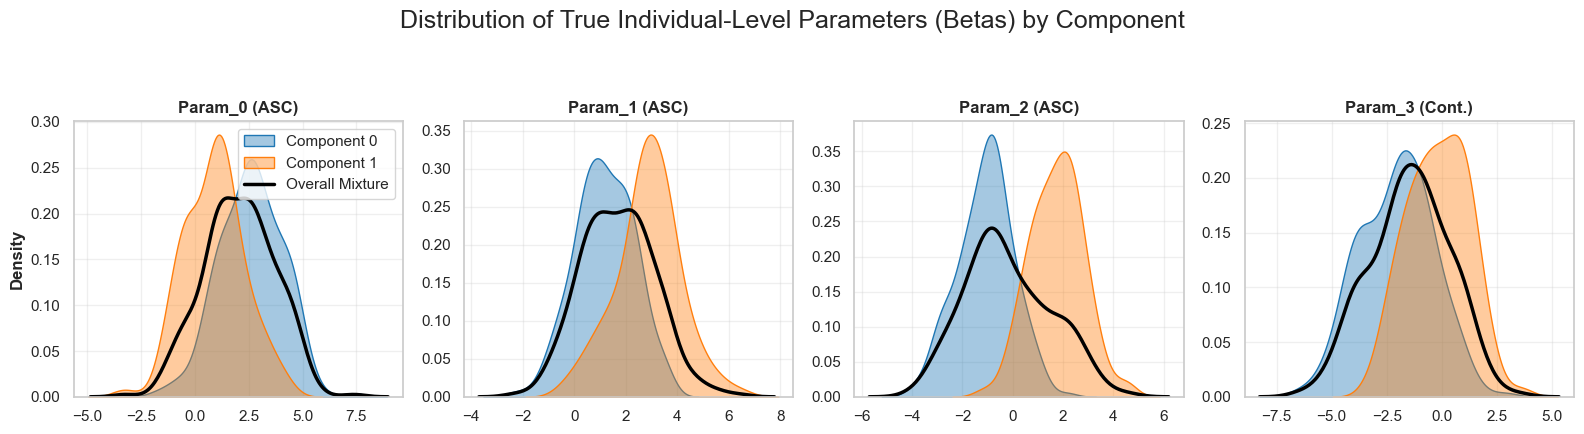

In [36]:
# ==============================================================================
# PLOT: True Beta Mixture Distributions
# ==============================================================================
def plot_beta_mixture_distributions(betas, indicators, K, p_names):
    n_params = len(p_names)
    fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))
 
    if n_params == 1:
        axes = [axes]
 
    colors = sns.color_palette("tab10", K)
 
    for p in range(n_params):
        ax = axes[p]
        for k in range(K):
            comp_betas = betas[indicators == k, p]
            if len(comp_betas) > 1:
                sns.kdeplot(comp_betas, ax=ax, fill=True, color=colors[k],
                            alpha=0.4, label=f"Component {k}")
 
        sns.kdeplot(betas[:, p], ax=ax, color="black", linewidth=2.5, label="Overall Mixture")
 
        ax.set_title(p_names[p], fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylabel("Density" if p == 0 else "", fontweight='bold')
 
        if p == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
            ax.legend(*zip(*unique), loc='upper right')
 
    plt.suptitle("Distribution of True Individual-Level Parameters (Betas) by Component",
                 fontsize=18, y=1.08)
    plt.tight_layout()
    plt.show()
 
 
print("\nPlotting Beta Mixture Distributions...")
param_names_labeled = [
    f"Param_{i} (ASC)" if i < (A - 1) else f"Param_{i} (Cont.)"
    for i in range(P)
]
plot_beta_mixture_distributions(
    betas=sim_data["TRUE_BETA"],
    indicators=sim_data["TRUE_INDICATORS"],
    K=sim_data["K"],
    p_names=param_names_labeled
)

In [37]:
# ==============================================================================
# 2. MODEL BUILDING
# ==============================================================================
# Prior hyperparameters matching rhierMnlRwMixture R defaults:
#
#   A_delta = 0.01   =>  Prior precision on vec(Delta): Ad = 0.01 * I
#                        i.e. prior covariance = 100 * I  (diffuse)
#
#   a_mu    = 0.01   =>  Prior on mu_k|Sigma_k: N(0, Sigma_k / a_mu)
#                        R default Amu = 0.01
#                        FIXED from original Python (was 1.0, now 0.01)
#
#   dirichlet_a = 5.0 => Prior on pvec: Dirichlet(5, ..., 5)
#                        R default a = rep(5, ncomp)
#                        FIXED from original Python (was 1.0, now 5.0)
#
#   nu = n_params + 3 => Wishart df for precision prior (= IW df for Sigma)
#   V  = nu * I       => IW location, so V_inv = (1/nu) * I used in Wishart
#
# NOTE on mu_k prior derivation:
#   R specifies:  mu_j | Sigma_j ~ N(mubar, Sigma_j * Amu^{-1})
#   Precision of mu_j = Amu * Sigma_j^{-1}
#   If Sigma_j^{-1} = L @ L.T  (Cholesky of precision),
#   then Precision_mu = Amu * L @ L.T = (sqrt(Amu)*L) @ (sqrt(Amu)*L).T
#   => precision_factor for mu_j = sqrt(Amu) * L_inv_chol  ✓
 
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )
 
 
def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )
 
 
def build_mixture_hmnl_model(
        data_dict,
        A_delta=0.01,       # R: Ad = 0.01 * I  (prior precision on Delta)
        a_mu=0.01,          # R: Amu = 0.01      FIXED (was 1.0)
        dirichlet_a=5.0     # R: a = rep(5,ncomp) FIXED (was 1.0)
):
    """
    Builds a Liesel probabilistic model for HMNL with mixture-of-normals
    heterogeneity, matching the prior structure of rhierMnlRwMixture.
 
    Parameters
    ----------
    data_dict   : dict with keys X, y, Z, unit_idx, n_units, n_params, K, Z
    A_delta     : Prior precision scalar for Delta  (R: Ad = A_delta * I)
    a_mu        : Prior precision scalar for mu_k|Sigma_k  (R: Amu)
    dirichlet_a : Dirichlet concentration for pvec  (R: a = rep(dirichlet_a, K))
    """
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K        = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None
 
    # ------------------------------------------------------------------
    # Wishart prior hyperparameters for Sigma_k^{-1}
    # R: Sigma_j ~ IW(nu, V)  <=>  Sigma_j^{-1} ~ Wishart(nu, V^{-1})
    # R defaults: nu = nvar + 3,  V = nu * I  =>  V^{-1} = (1/nu) * I
    # ------------------------------------------------------------------
    nu    = float(n_params + 3)
    V     = nu * jnp.eye(n_params)                  # R: V = nu * I
    V_inv = jnp.linalg.inv(V)                       # = (1/nu) * I
    Vinv_chol   = jnp.linalg.cholesky(V_inv)        # lower-triangular
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K, n_params, n_params))
 
    # ------------------------------------------------------------------
    # pvec ~ Dirichlet(a)    R default: a = rep(5, ncomp)
    # FIXED: dirichlet_a = 5.0  (was 1.0)
    # ------------------------------------------------------------------
    alpha = jnp.ones(K) * dirichlet_a
    pvec = lsl.Var.new_param(
        value=jnp.ones(K) / K,
        distribution=lsl.Dist(tfd.Dirichlet, concentration=alpha),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")
 
    # ------------------------------------------------------------------
    # Sigma_k^{-1} ~ Wishart(nu, V^{-1})
    # Parameterised via Cholesky: sigma_inv_chol_k such that
    #   Sigma_k^{-1} = sigma_inv_chol_k @ sigma_inv_chol_k.T
    # ------------------------------------------------------------------
    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.broadcast_to(jnp.eye(n_params)[None], (K, n_params, n_params)),
        distribution=lsl.Dist(
            make_wishart,
            df=jnp.full(K, nu),
            scale_tril=Vinv_chol_K
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_k_latent"
    )
 
    # ------------------------------------------------------------------
    # mu_k | Sigma_k ~ N(0, Sigma_k / Amu)
    # Precision of mu_k = Amu * Sigma_k^{-1} = Amu * L @ L.T
    # precision_factor = sqrt(Amu) * L   (so that pf @ pf.T = Amu * L @ L.T)
    # FIXED: a_mu = 0.01  (was 1.0)
    # ------------------------------------------------------------------
    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L,
        L=sigma_inv_chol_k,
        name="mu_prec_factor_k"
    )
 
    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=jnp.zeros(n_params),
            precision_factor=mu_prec_factor_k
        ),
        name="mu_k"
    )
 
    # ------------------------------------------------------------------
    # Delta ~ N(0, Ad^{-1})  where Ad = A_delta * I
    # precision_factor = sqrt(A_delta) * I  => Precision = A_delta * I
    # => Cov(delta) = (1 / A_delta) * I = 100 * I   (for A_delta=0.01)
    # R: delta = vec(Delta) ~ N(deltabar=0, Ad^{-1}=100*I)  ✓
    # ------------------------------------------------------------------
    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
 
        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params)
 
        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision,
                loc=jnp.zeros(n_params),
                precision_factor=Delta_prec_factor
            ),
            name="Delta"
        )
        z_delta = lsl.Var.new_calc(
            lambda z, d: z @ d, z=Z_var, d=Delta, name="z_delta"
        )
 
    # ------------------------------------------------------------------
    # Sigma_k (covariance) from precision Cholesky
    # Sigma_k = (L @ L.T)^{-1}  where L = sigma_inv_chol_k
    # Small jitter 1e-6 * I for numerical stability
    # ------------------------------------------------------------------
    sigma_chol_k = lsl.Var.new_calc(
        lambda L: jax.vmap(
            lambda Lk: jnp.linalg.cholesky(
                jnp.linalg.inv(Lk @ Lk.T) + 1e-6 * jnp.eye(n_params)
            )
        )(L),
        L=sigma_inv_chol_k,
        name="sigma_chol_k"
    )
 
    # ------------------------------------------------------------------
    # beta_i location: E[beta_i | k] = Z[i,] @ Delta + mu_k
    # Shape: (n_units, K, n_params)
    # ------------------------------------------------------------------
    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta, mu=mu_k,
            name="beta_loc"
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K, n_params)),
            mu=mu_k,
            name="beta_loc"
        )
 
    # ------------------------------------------------------------------
    # beta_i ~ MixtureSameFamily(pvec, MVN(beta_loc[i,k], Sigma_k))
    # R: u_i ~ N(mu_ind, Sigma_ind), ind ~ Categorical(pvec)
    # ------------------------------------------------------------------
    def make_beta_mixture(pvec, locs, scale_trils):
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfd.MultivariateNormalTriL(
                loc=locs,
                scale_tril=scale_trils[None]   # broadcast K over n_units
            )
        )
 
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture,
            pvec=pvec,
            locs=beta_loc,
            scale_trils=sigma_chol_k
        ),
        name="beta_i"
    )
 
    # ------------------------------------------------------------------
    # Likelihood: y_it ~ Categorical(softmax(X_it @ beta_i))
    # ------------------------------------------------------------------
    X_var   = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
 
    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded"
    )
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var, b=beta_expanded,
        name="logits"
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits),
        name="y"
    )
 
    return lsl.Model([y_var])

In [ ]:
# ==============================================================================
# 3. MCMC INFERENCE
# ==============================================================================
def run_mixture_inference(model, data_dict, chains=4, warmup=1000, posterior=2000, seed=123):
    """
    Runs NUTS sampling for the HMNL mixture model.
 
    Kernel assignment mirrors the block structure of Gibbs steps in R:
        - pvec_latent       (R: Dirichlet Gibbs step)
        - sigma_inv_chol_k  (R: Wishart Gibbs step)
        - mu_k              (R: Normal Gibbs step)
        - Delta             (R: Normal Gibbs step for vec(Delta))
        - beta_i            (R: RW-MH per unit — replaced by joint NUTS)
    """
    has_Z = data_dict.get("Z") is not None
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    eb.add_kernel(gs.NUTSKernel(["pvec_latent"]))                              # isolated
    eb.add_kernel(gs.NUTSKernel(["mu_k", "sigma_inv_chol_k_latent"], mm_diag=False))
    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)
    engine = eb.build()
    engine.sample_all_epochs()
    return engine.get_results(), engine.get_results().get_posterior_samples()
 
 
print("Building Mixture of Normals HMNL Model...")
choice_data = sim_data
 
# Build with corrected prior hyperparameters matching R defaults
hmnl_model = build_mixture_hmnl_model(
    choice_data,
    A_delta=0.01,       # R: Ad = 0.01 * I
    a_mu=0.01,          # R: Amu = 0.01  (FIXED from 1.0)
    dirichlet_a=2 .0     # R: a = rep(5, ncomp)  (FIXED from 1.0)
)
 
start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, choice_data, chains=4, warmup=1000, posterior=2000
)
formatted_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"Sampling finished in {formatted_time}")

Building Mixture of Normals HMNL Model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:35<00:00, 11.98s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 2, 3, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for ke

Sampling finished in 0:20:19


In [39]:
# ==============================================================================
# 4. LABEL SWITCHING RESOLUTION (PRA — Pivotal Reordering Algorithm)
# ==============================================================================
def pra(xi_star, xi_draws):
    """
    Pivotal Reordering Algorithm.
    Finds per-draw permutations that minimise squared distance to the pivot xi_star.
 
    Parameters
    ----------
    xi_star  : (K, J) pivot (e.g. posterior mean of one chain)
    xi_draws : (m, K, J) draws across all chains/iterations
 
    Returns
    -------
    perms     : (m, K) permutation indices
    relabeled : (m, K, J) reordered draws
    """
    m, K, J = xi_draws.shape
    perms     = np.empty((m, K), dtype=int)
    relabeled = np.empty_like(xi_draws)
    for t in range(m):
        cost = np.sum(
            (xi_star[:, None, :] - xi_draws[t, None, :, :]) ** 2, axis=-1
        )
        _, perms[t] = linear_sum_assignment(cost)
        relabeled[t] = xi_draws[t, perms[t], :]
    return perms, relabeled
 
 
def apply_permutations(draws, perms):
    m, K = perms.shape
    relabeled = np.empty_like(draws)
    for t in range(m):
        relabeled[t] = draws[t, perms[t]]
    return relabeled
 
 
def resolve_label_switching(samples_dict, pivot_chain_idx=0):
    print("\nStarting Pivotal Reordering Algorithm (PRA)...")
    mu             = samples_dict["mu_k"]
    n_chains, n_draws, K, n_params = mu.shape
    m              = n_chains * n_draws
 
    mu_flat        = mu.reshape(m, K, n_params)
    xi_star        = np.mean(mu[pivot_chain_idx], axis=0)   # (K, n_params) pivot
 
    perms, relabeled_mu_flat = pra(xi_star, mu_flat)
 
    sorted_samples          = samples_dict.copy()
    sorted_samples["mu_k"]  = relabeled_mu_flat.reshape(n_chains, n_draws, K, n_params)
 
    # Relabel sigma
    sigma       = samples_dict["sigma_inv_chol_k_latent"]
    sigma_shape = sigma.shape
    sigma_flat  = sigma.reshape(m, K, *sigma_shape[3:])
    relabeled_sigma_flat = apply_permutations(sigma_flat, perms)
    sorted_samples["sigma_inv_chol_k_latent"] = relabeled_sigma_flat.reshape(sigma_shape)
 
    # Relabel pvec (transform latent -> simplex, permute, store)
    pvec_latent  = samples_dict["pvec_latent"]
    bijector_pvec = tfb.SoftmaxCentered()
    pvec_simplex  = bijector_pvec.forward(pvec_latent)      # (..., K)
 
    pvec_flat            = pvec_simplex.reshape(m, K)
    relabeled_pvec_flat  = apply_permutations(pvec_flat, perms)
    sorted_samples["pvec"] = relabeled_pvec_flat.reshape(n_chains, n_draws, K)
 
    print("Label switching resolved! All chains are now aligned.")
    return sorted_samples
 
 
posterior_samples_sorted = resolve_label_switching(posterior_samples, pivot_chain_idx=0)



Starting Pivotal Reordering Algorithm (PRA)...
Label switching resolved! All chains are now aligned.



=== MCMC Convergence Summary ===


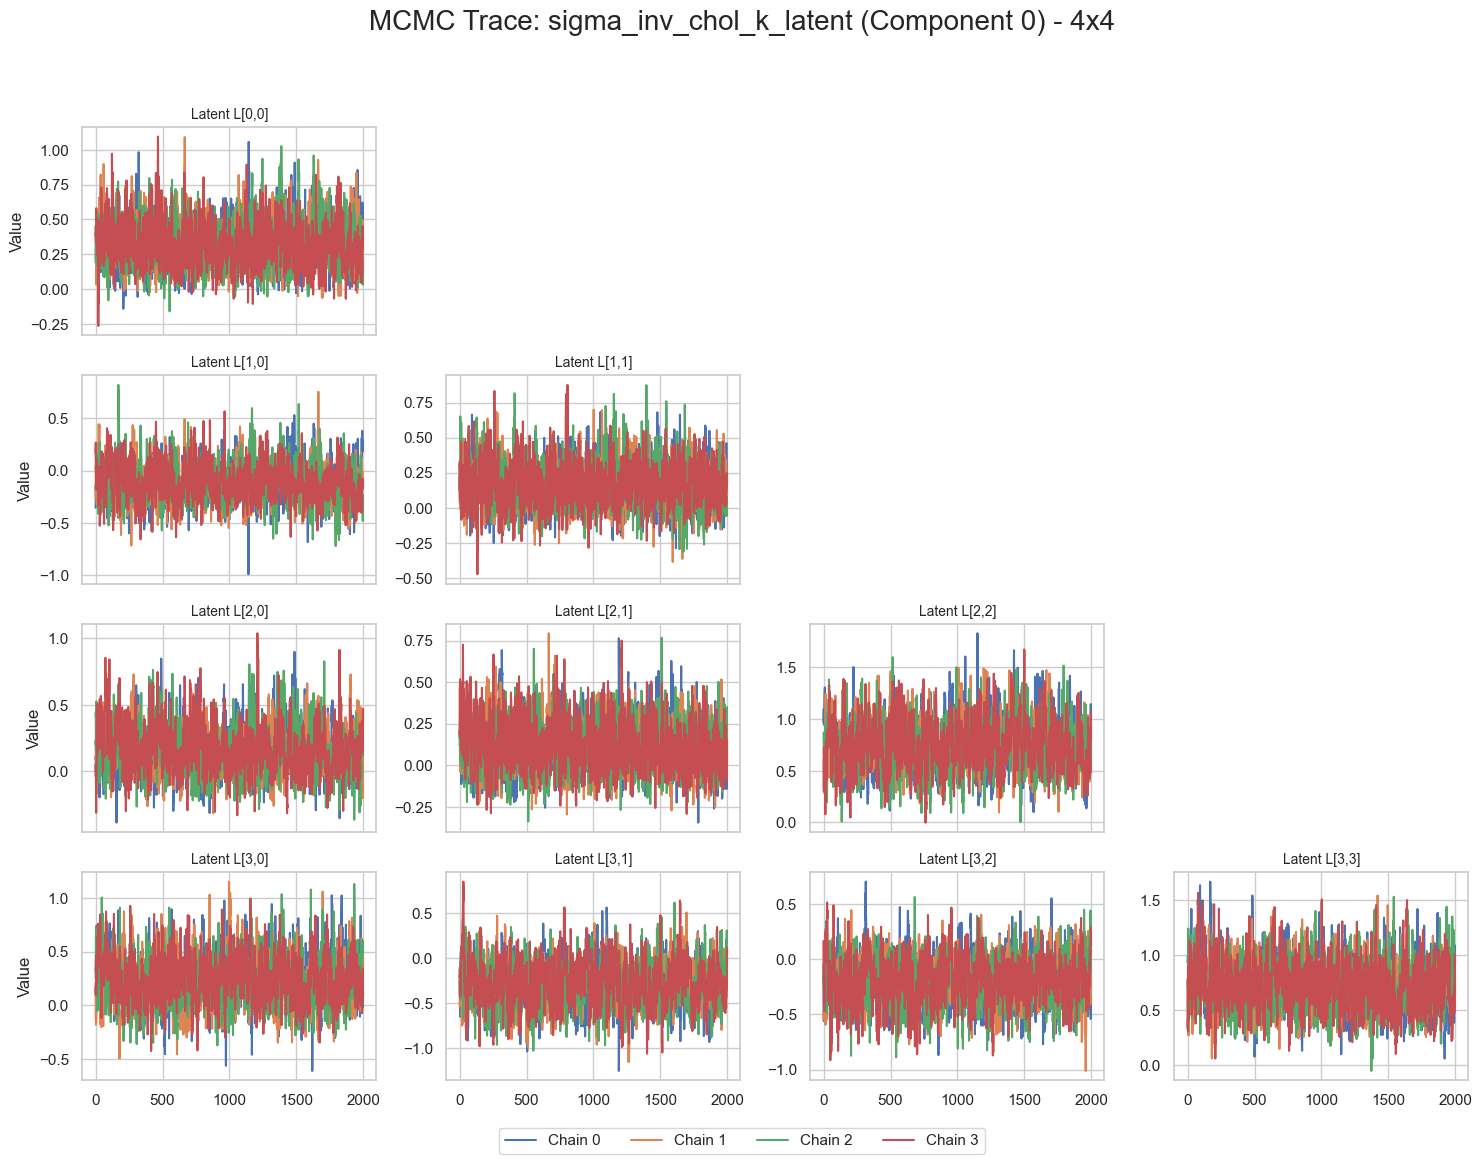

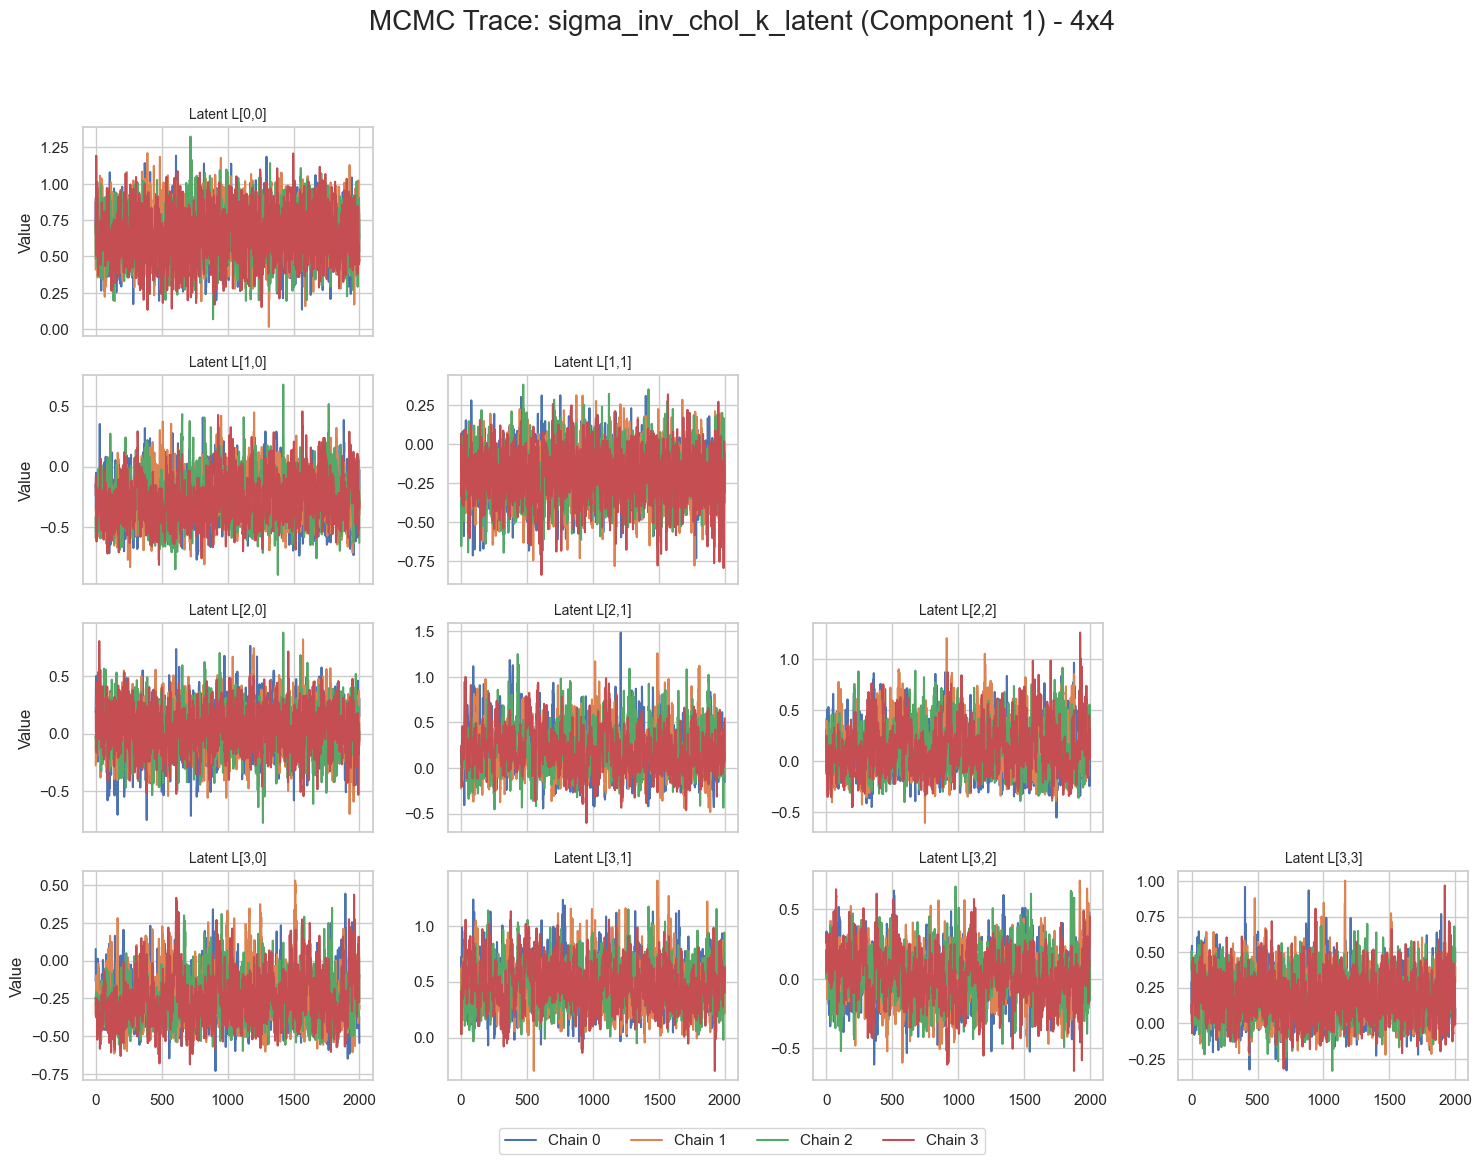

In [40]:
# ==============================================================================
# 5. MCMC DIAGNOSTICS & TRACE PLOTS
# ==============================================================================
print("\n=== MCMC Convergence Summary ===")
summary = gs.Summary(mcmc_results)
 
 
def plot_cholesky_traces(samples_dict, n_params, k_idx=0,
                         param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape
 
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])
 
    latent_idx = 0
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}")
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')
 
            ax.grid(True)
            if j == 0:
                ax.set_ylabel("Value")
 
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains,
               bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(
        f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params}",
        fontsize=20
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
 
 
for k in range(K):
    plot_cholesky_traces(posterior_samples_sorted, n_params=P, k_idx=k)



Recovering Covariance Matrices (Sigma_k) from SORTED samples...


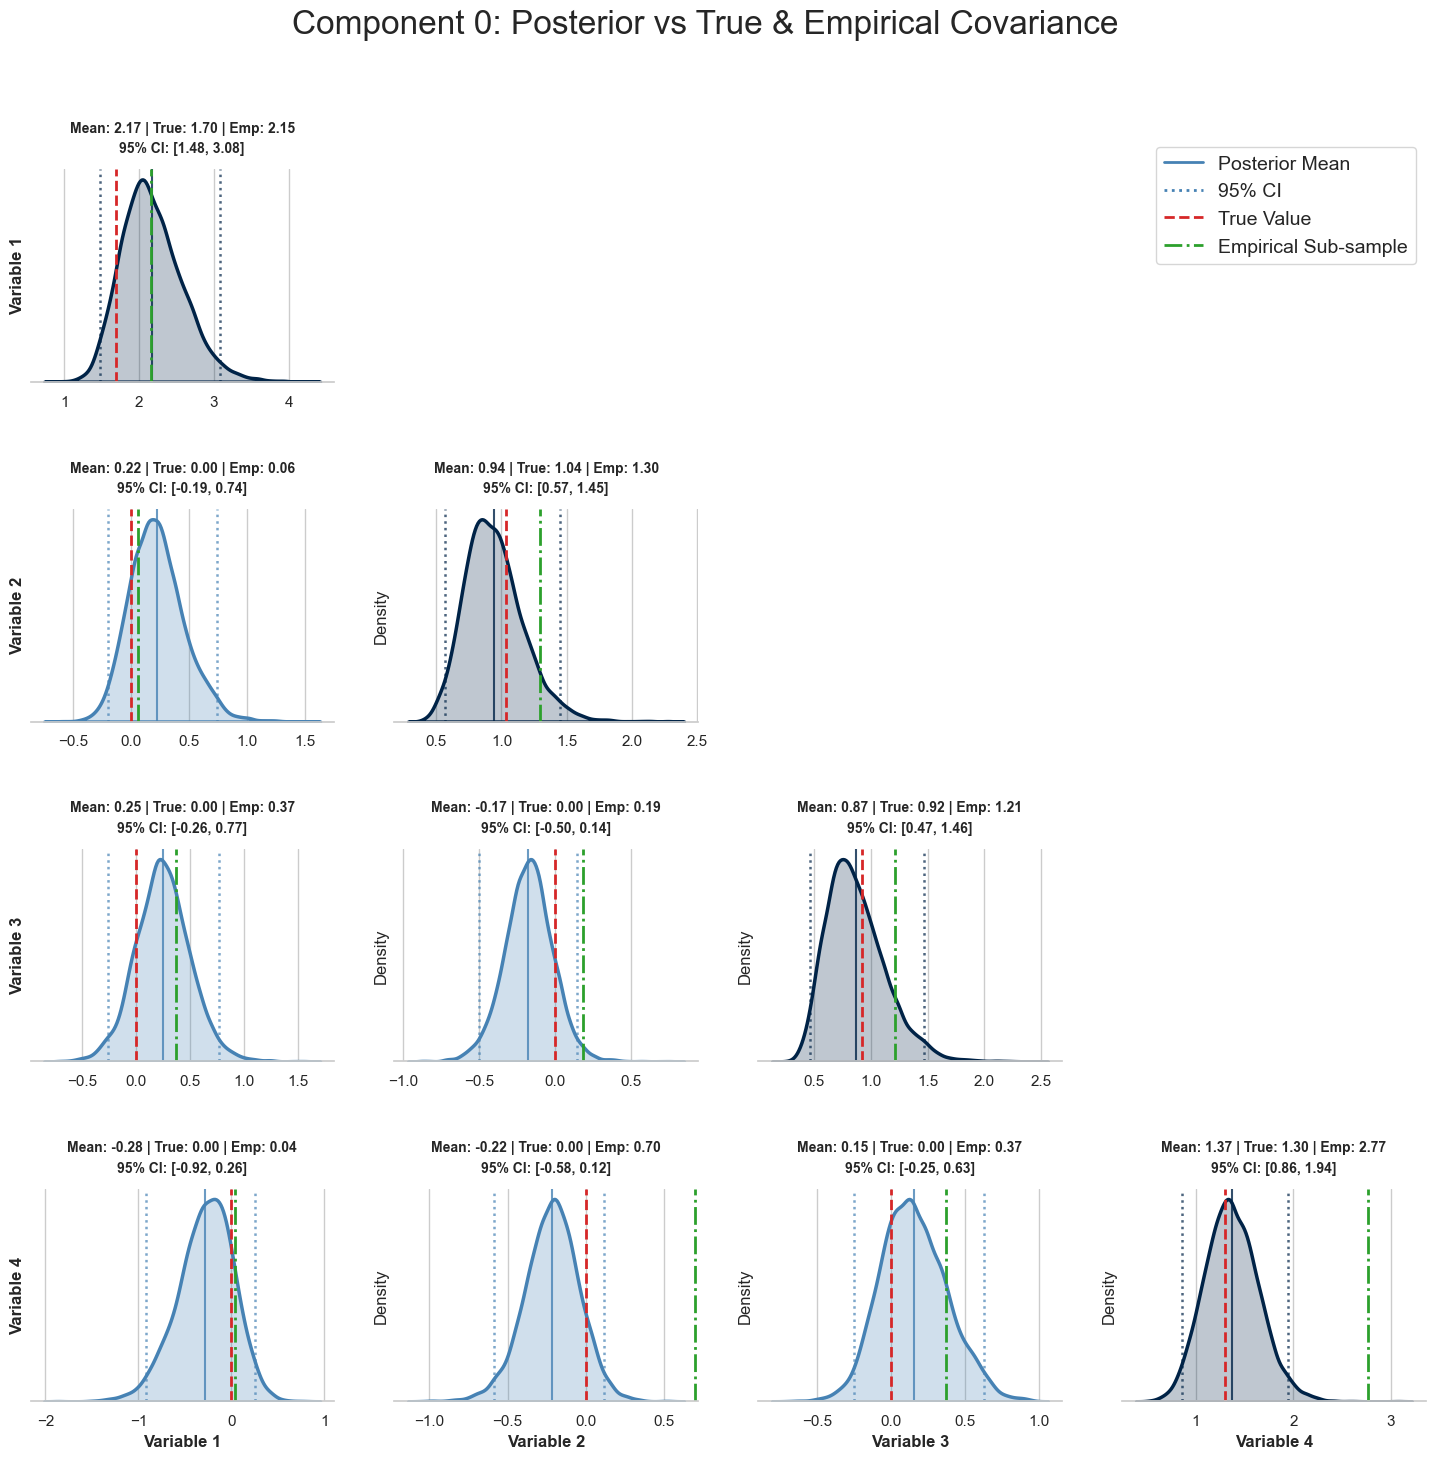

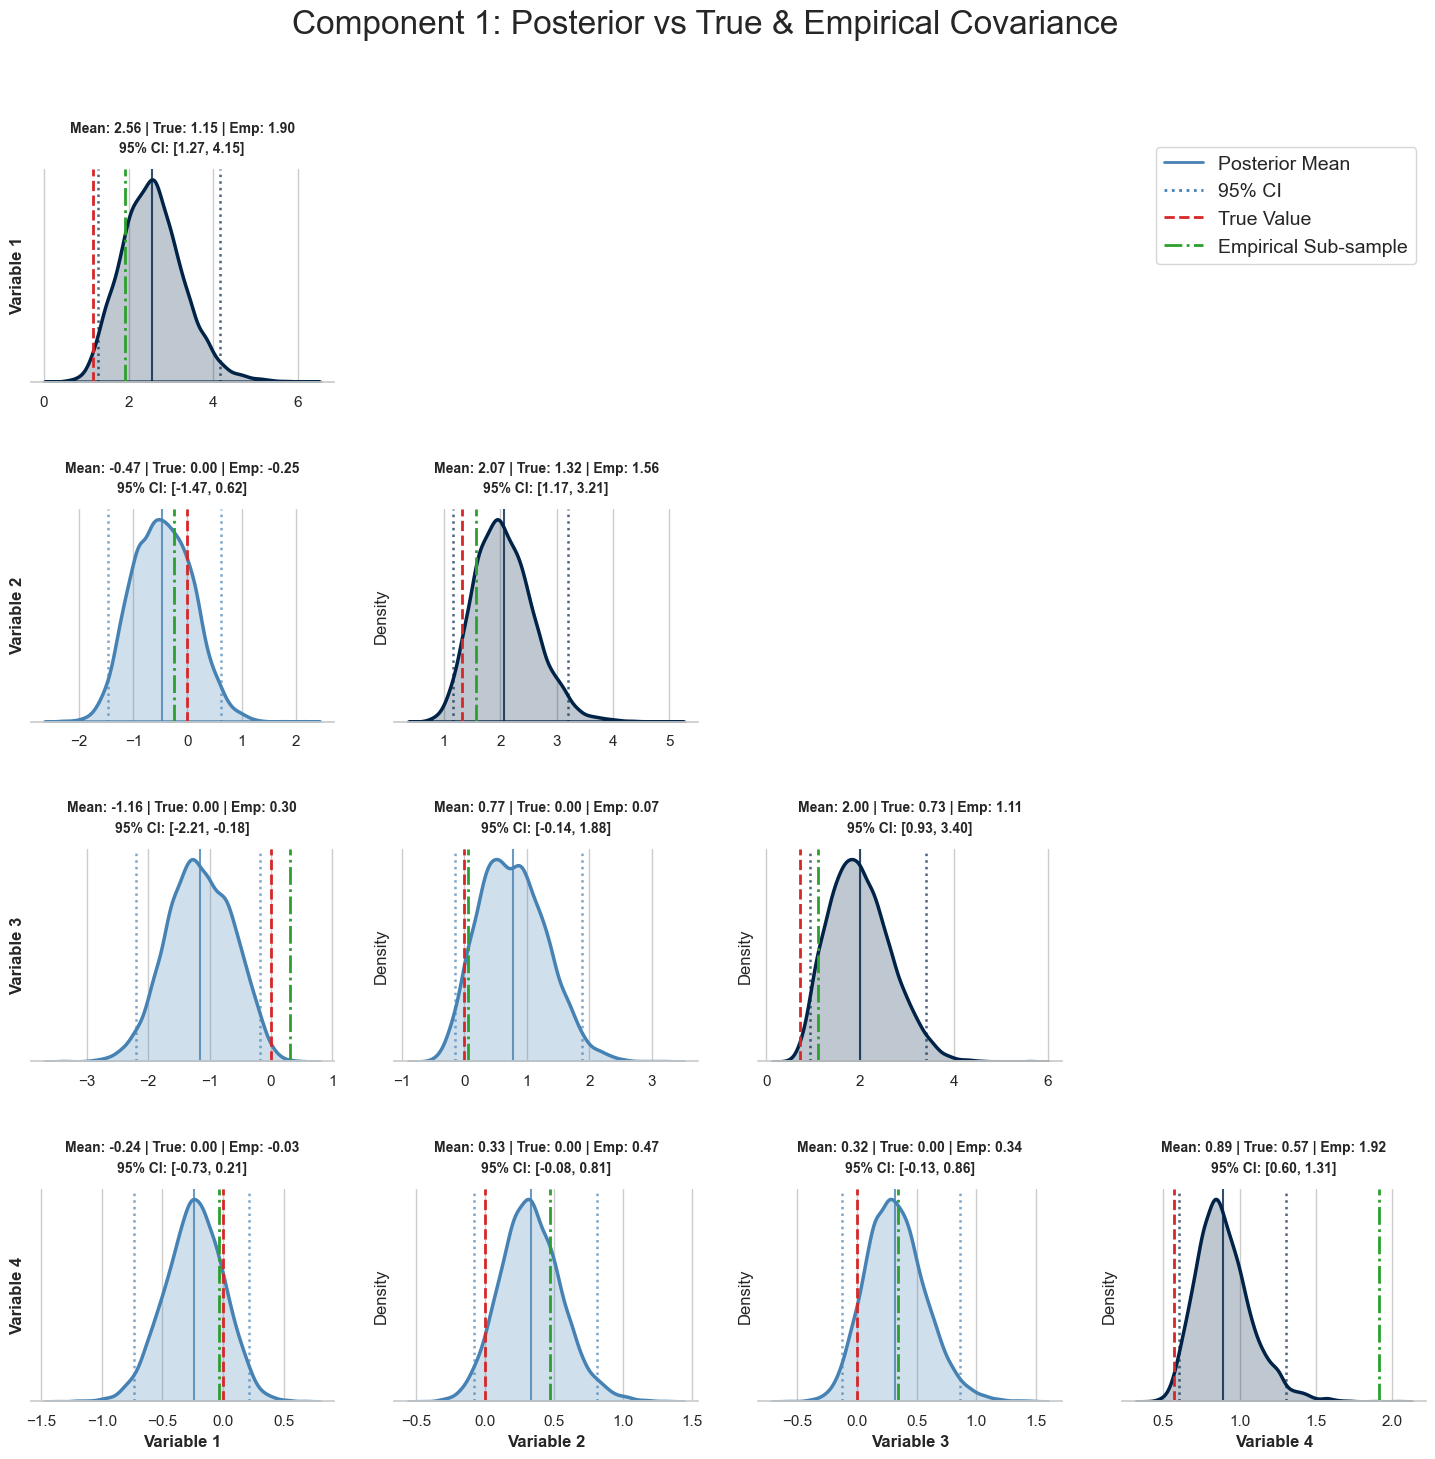

In [41]:
# ==============================================================================
# 6. COVARIANCE RECOVERY
# ==============================================================================
print("\nRecovering Covariance Matrices (Sigma_k) from SORTED samples...")
 
bijector_tril = tfb.FillScaleTriL()
 
 
def latent_to_sigma(latent_vec):
    """Convert FillScaleTriL latent vector -> Sigma (covariance matrix)."""
    L           = bijector_tril.forward(latent_vec)    # Cholesky of Precision
    precision   = L @ L.T
    return jnp.linalg.inv(precision)
 
 
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
latent_samples_sorted = posterior_samples_sorted["sigma_inv_chol_k_latent"]
sigma_samples_sorted  = v_latent_to_sigma(latent_samples_sorted)  # (chains, draws, K, P, P)
 
 
def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None,
                                   component_idx=0):
    n_dim            = samples.shape[-1]
    fig, axes        = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
 
    diag_color    = "#002347"
    off_diag_color = "#4682B4"
    true_val_color = "#D62728"
    emp_val_color  = "#2CA02C"
 
    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off')
                continue
 
            data_vec     = flattened_samples[:, i, j]
            current_color = diag_color if (i == j) else off_diag_color
            post_mean    = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
 
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-",  lw=1.5, alpha=0.8)
            ax.axvline(ci_low,    color=current_color, linestyle=":",  lw=1.8, alpha=0.7)
            ax.axvline(ci_high,   color=current_color, linestyle=":",  lw=1.8, alpha=0.7)
 
            title_parts = [f"Mean: {post_mean:.2f}"]
            if true_matrix is not None:
                ax.axvline(true_matrix[i, j], color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_matrix[i, j]:.2f}")
            if empirical_matrix is not None:
                ax.axvline(empirical_matrix[i, j], color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {empirical_matrix[i, j]:.2f}")
 
            title_str = f"{' | '.join(title_parts)}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
 
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j + 1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i + 1}", fontsize=12, fontweight='bold')
 
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% CI'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Sub-sample')
    ]
    fig.legend(handles=legend_elements, loc='upper right',
               bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(
        f"Component {component_idx}: Posterior vs True & Empirical Covariance",
        fontsize=24, y=0.98
    )
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()
 
 
for k in range(K):
    comp_mask         = choice_data["TRUE_INDICATORS"] == k
    comp_betas        = choice_data["TRUE_BETA"][comp_mask]
    empirical_sigma_k = jnp.cov(comp_betas, rowvar=False) if len(comp_betas) > 1 else None
    plot_final_covariance_complete(
        samples=sigma_samples_sorted[:, :, k, :, :],
        true_matrix=choice_data["TRUE_SIGMA_K"][k],
        empirical_matrix=empirical_sigma_k,
        component_idx=k
    )



=== Detailed Delta Parameter Diagnostics (Goose Style) ===


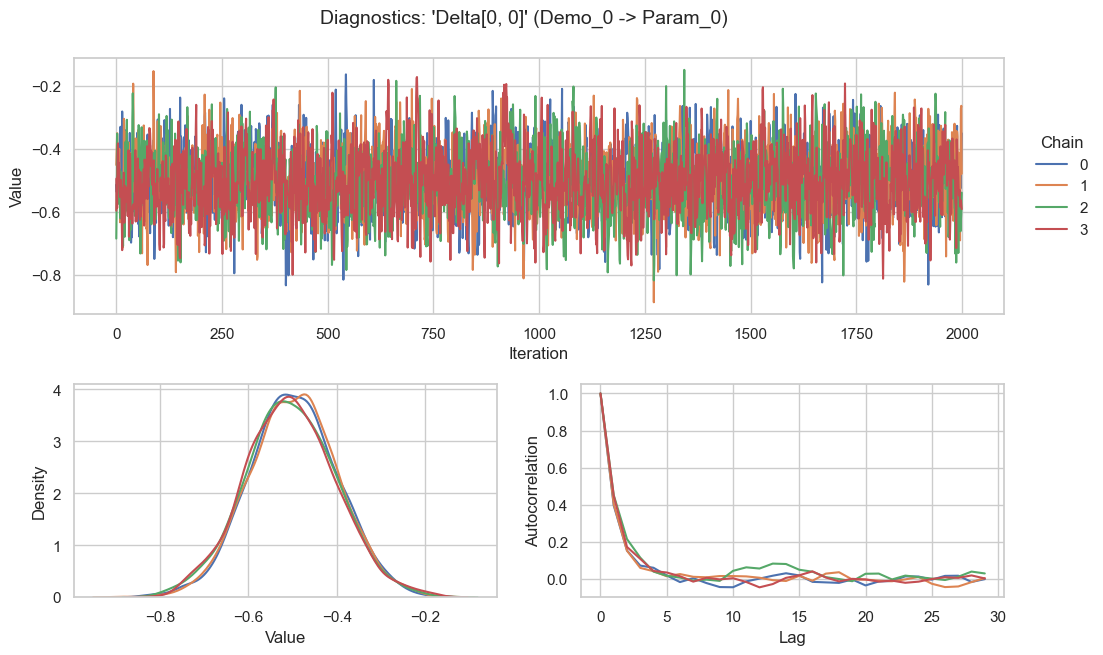

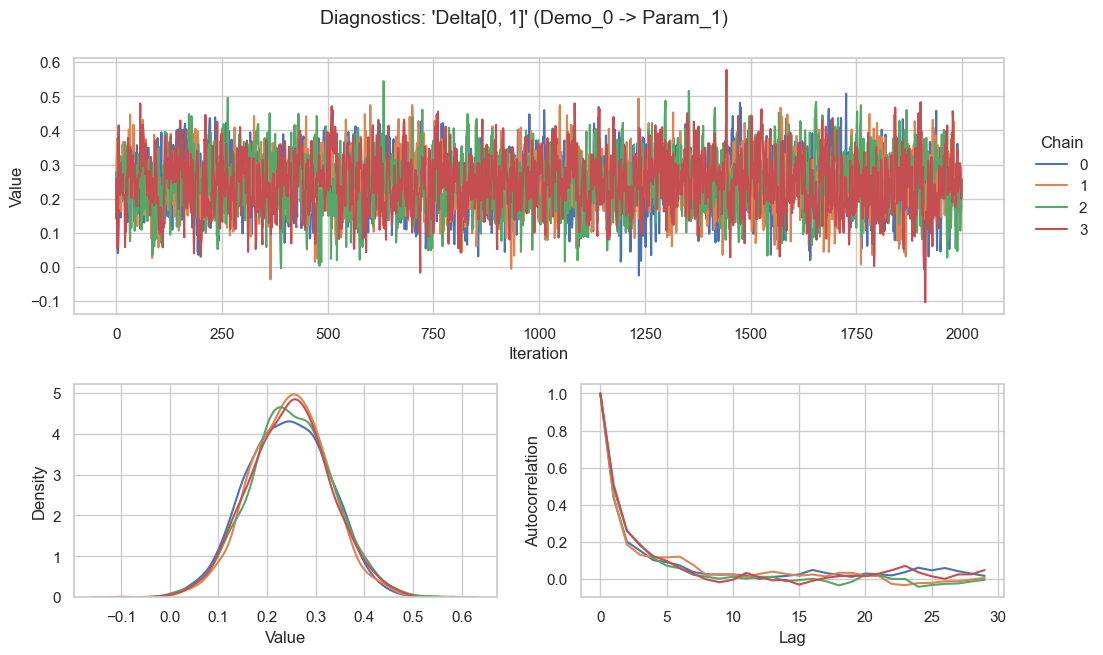

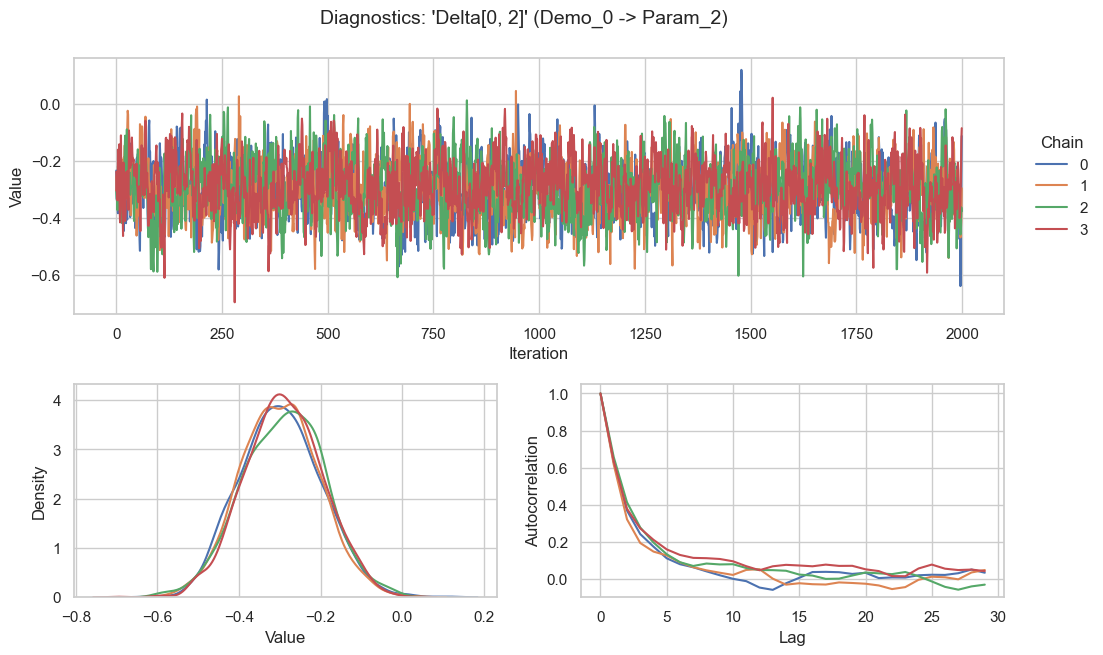

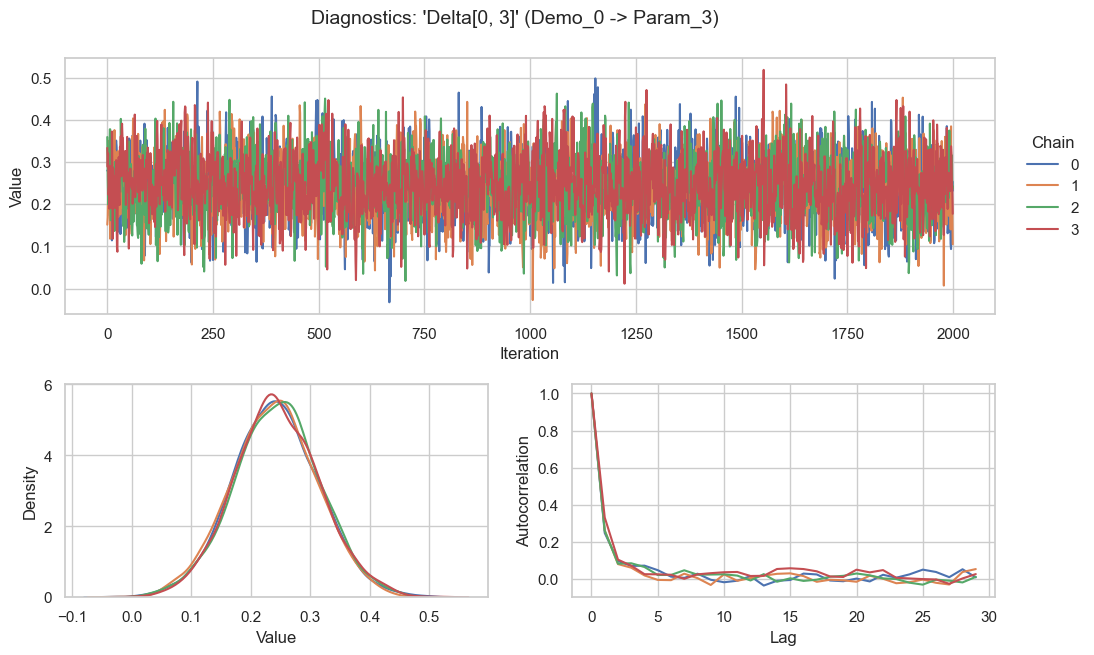

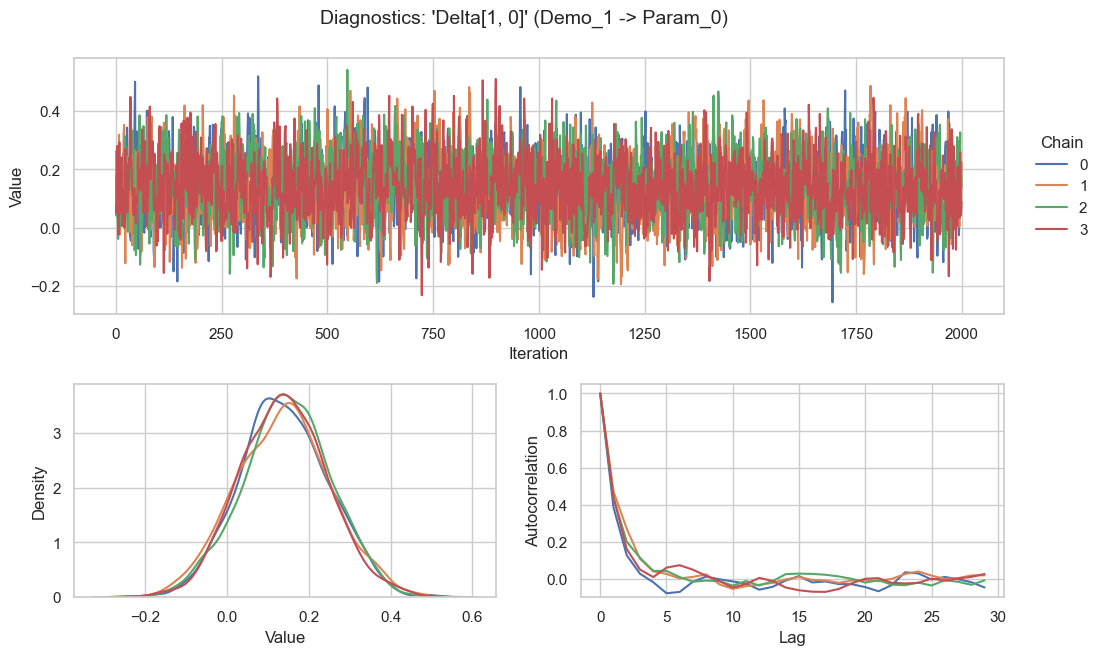

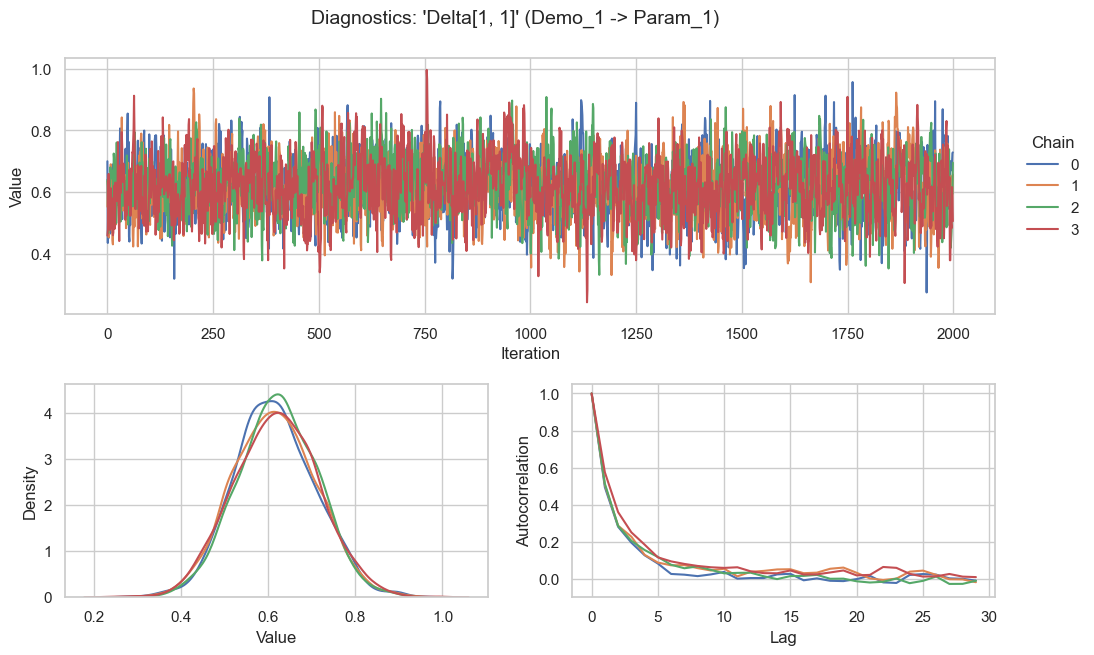

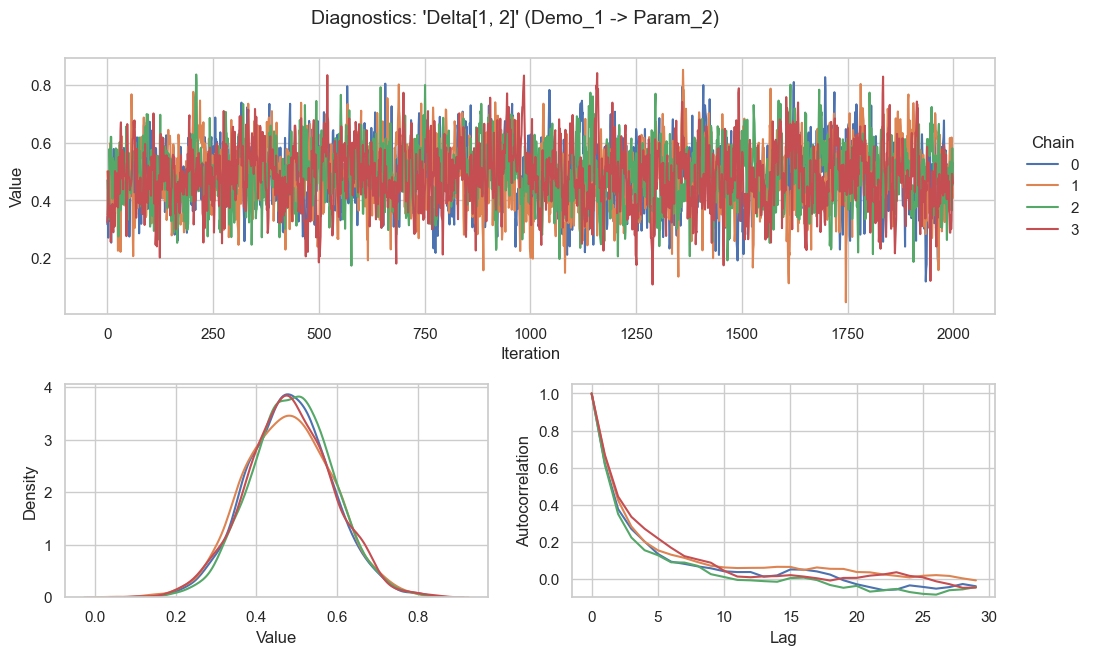

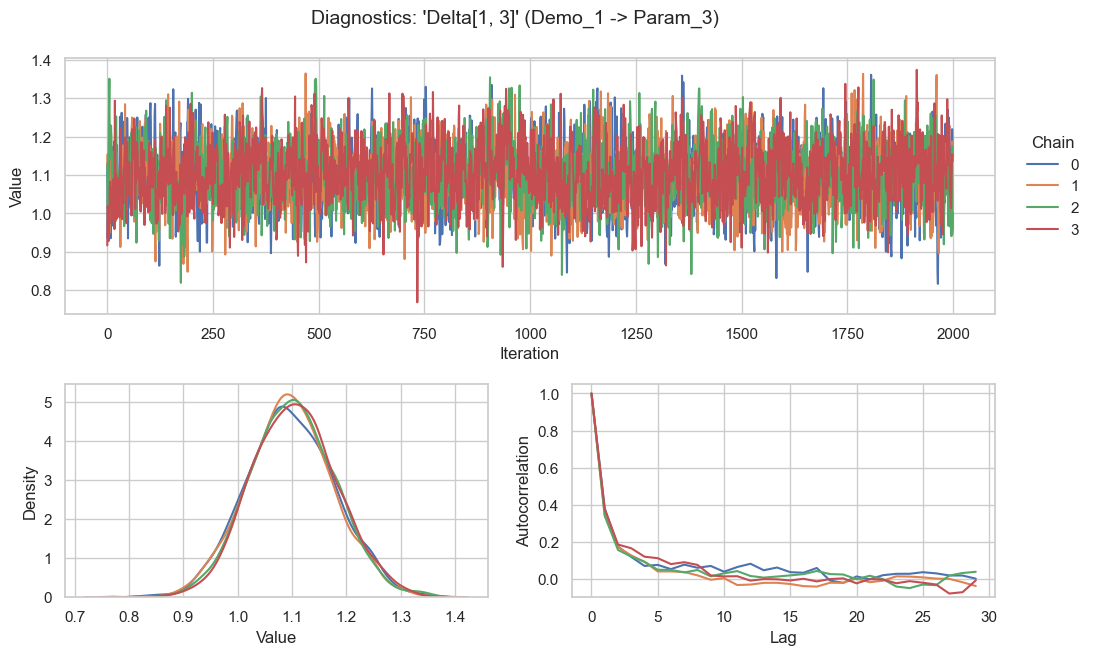

In [42]:
# ==============================================================================
# 7. GOOSE-STYLE DIAGNOSTICS
# ==============================================================================
def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm       = np.sum(x_centered ** 2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    return (acf[acf.size // 2:] / norm)[:nlags]
 
 
def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx,
                                 demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Diagnostics: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})",
        fontsize=14, y=0.95
    )
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)
 
    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
 
    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)
 
    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(
            compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags), alpha=1
        )
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    plt.show()
 
 
print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_samples = posterior_samples_sorted["Delta"]
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_samples, demo_idx=i, param_idx=j,
            demo_name=f"Demo_{i}", param_name=f"Param_{j}"
        )



=== Global Parameters (Baseline Means mu_k) Summary Tables ===

--- Sorted MCMC Component 0 (Mapped to True Component 0) ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,2.5266,2.4910,0.0356,0.1877
Param_1,1.0739,1.0874,0.0135,0.1352
Param_2,-1.2251,-1.3067,0.0816,0.1866
Param_3,-2.0395,-2.3029,0.2634,0.2225



--- Sorted MCMC Component 1 (Mapped to True Component 1) ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,1.0687,1.5209,0.4522,0.3209
Param_1,2.6586,2.5775,0.0811,0.3329
Param_2,1.7922,1.1930,0.5992,0.3724
Param_3,-0.2600,-0.4316,0.1716,0.1576



=== True distribution of Delta (Ground Truth) ===


...


=== Posterior distribution of Delta (mean + std) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.50 (0.10),0.25 (0.08),-0.29 (0.10),0.24 (0.07)
Demo_1,0.14 (0.11),0.62 (0.09),0.48 (0.11),1.10 (0.08)



=== ABSOLUTE DIFFERENCE in Delta (|True - Posterior|) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.080,0.077,0.155,0.026
Demo_1,0.281,0.111,0.025,0.041



Plotting Delta Distributions...


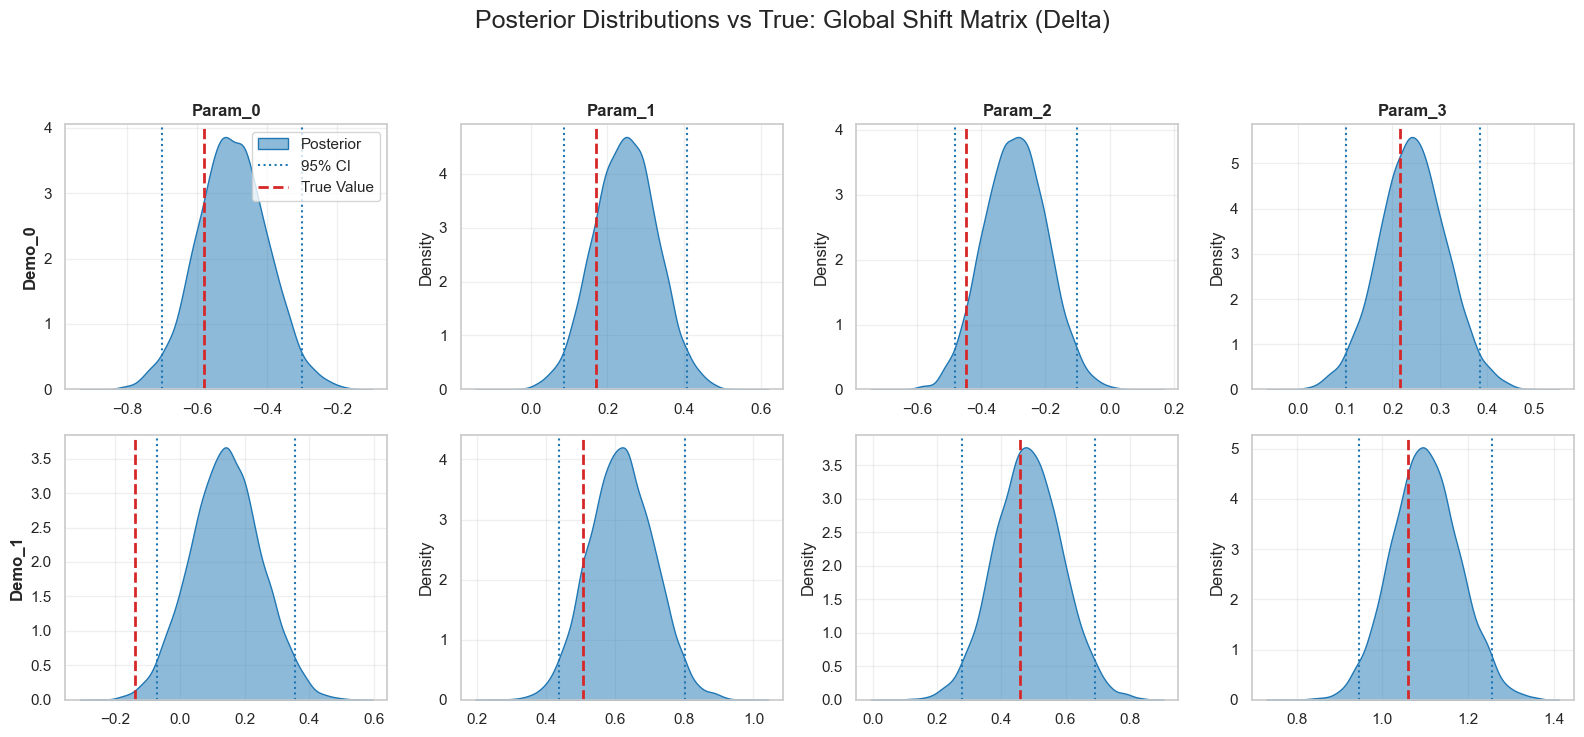

In [43]:
# ==============================================================================
# 8. GLOBAL PARAMETERS: BASELINE MEANS & DELTA
# ==============================================================================
def create_summary_table(t_mu, post_mu, p_names):
    return pd.DataFrame({
        'Parameter':      p_names,
        'True_Value':     t_mu,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Diff_Abs':       np.abs(t_mu - post_mu.mean(axis=0)),
        'Posterior_Std':  post_mu.std(axis=0)
    }).round(4).set_index("Parameter")
 
 
print("\n=== Global Parameters (Baseline Means mu_k) Summary Tables ===")
mu_samples_sorted      = posterior_samples_sorted["mu_k"]
mu_samples_sorted_flat = mu_samples_sorted.reshape(-1, K, P)
 
# Map sorted MCMC components to the True component indices via Hungarian algorithm
sorted_mu_mean = mu_samples_sorted_flat.mean(axis=0)                    # (K, P)
cost_matrix    = np.sum(
    (sorted_mu_mean[:, None, :] - choice_data["TRUE_MU_K"][None, :, :]) ** 2,
    axis=-1
)
_, true_mapping = linear_sum_assignment(cost_matrix)
 
for k in range(K):
    true_k = true_mapping[k]
    print(f"\n--- Sorted MCMC Component {k} (Mapped to True Component {true_k}) ---")
    display(create_summary_table(
        t_mu=choice_data["TRUE_MU_K"][true_k],
        post_mu=mu_samples_sorted_flat[:, k, :],
        p_names=param_names
    ))
 
 
def generate_delta_table(delta_draws, p_names, d_names):
    mean = np.mean(delta_draws, axis=0)
    std  = np.std(delta_draws,  axis=0)
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]:.2f} ({std[i, j]:.2f})"
    return df
 
 
def generate_delta_diff_table(t_delta, l_delta, p_names, d_names):
    diff_mean = np.abs(t_delta - np.mean(l_delta, axis=0))
    df        = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff_mean[i, j]:.3f}"
    return df
 
 
print("\n=== True distribution of Delta (Ground Truth) ===")
display(pd.DataFrame(choice_data["TRUE_DELTA"], index=demo_names, columns=param_names))
 
delta_samples_sorted = posterior_samples_sorted["Delta"].reshape(-1, D, P)
 
print("\n=== Posterior distribution of Delta (mean + std) ===")
display(generate_delta_table(delta_samples_sorted, param_names, demo_names))
 
print("\n=== ABSOLUTE DIFFERENCE in Delta (|True - Posterior|) ===")
display(generate_delta_diff_table(
    choice_data["TRUE_DELTA"], delta_samples_sorted, param_names, demo_names
))
 
 
def plot_delta_distributions(delta_samples, t_delta, p_names, d_names):
    n_demos, n_params = len(d_names), len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4 * n_params, 3.5 * n_demos))
 
    for d in range(n_demos):
        for p in range(n_params):
            ax    = axes[d, p] if n_demos > 1 else axes[p]
            samples = delta_samples[:, d, p]
            t_val   = t_delta[d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
 
            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior")
            ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
            ax.axvline(t_val,   color="#D62728", linestyle="--", lw=2,  label="True Value")
 
            if d == 0:
                ax.set_title(p_names[p], fontweight='bold')
            if p == 0:
                ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)
 
            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')
 
    plt.suptitle("Posterior Distributions vs True: Global Shift Matrix (Delta)",
                 fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()
 
 
print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_sorted, choice_data["TRUE_DELTA"], param_names, demo_names)


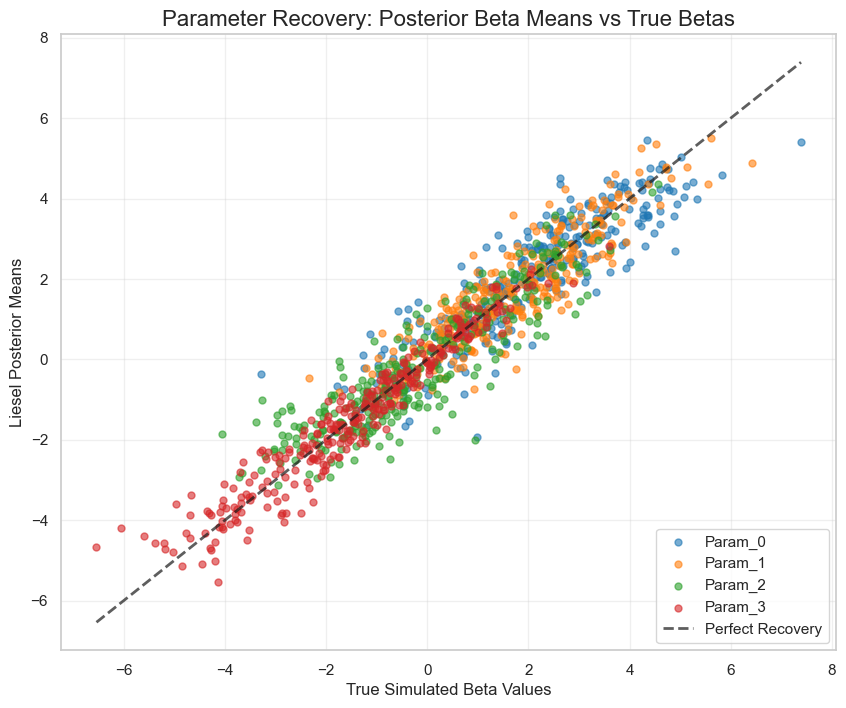


Plotting Household-Level Distributions...


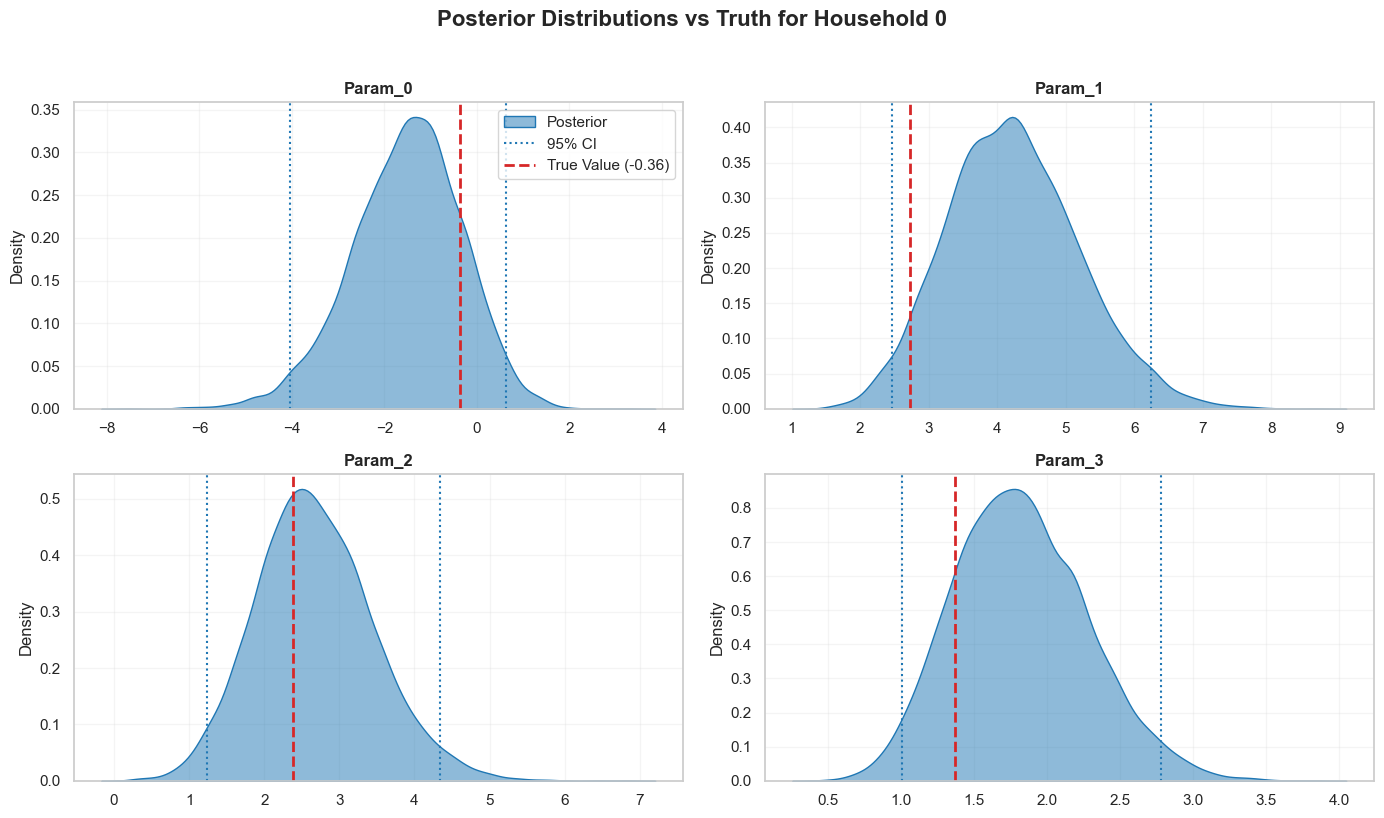

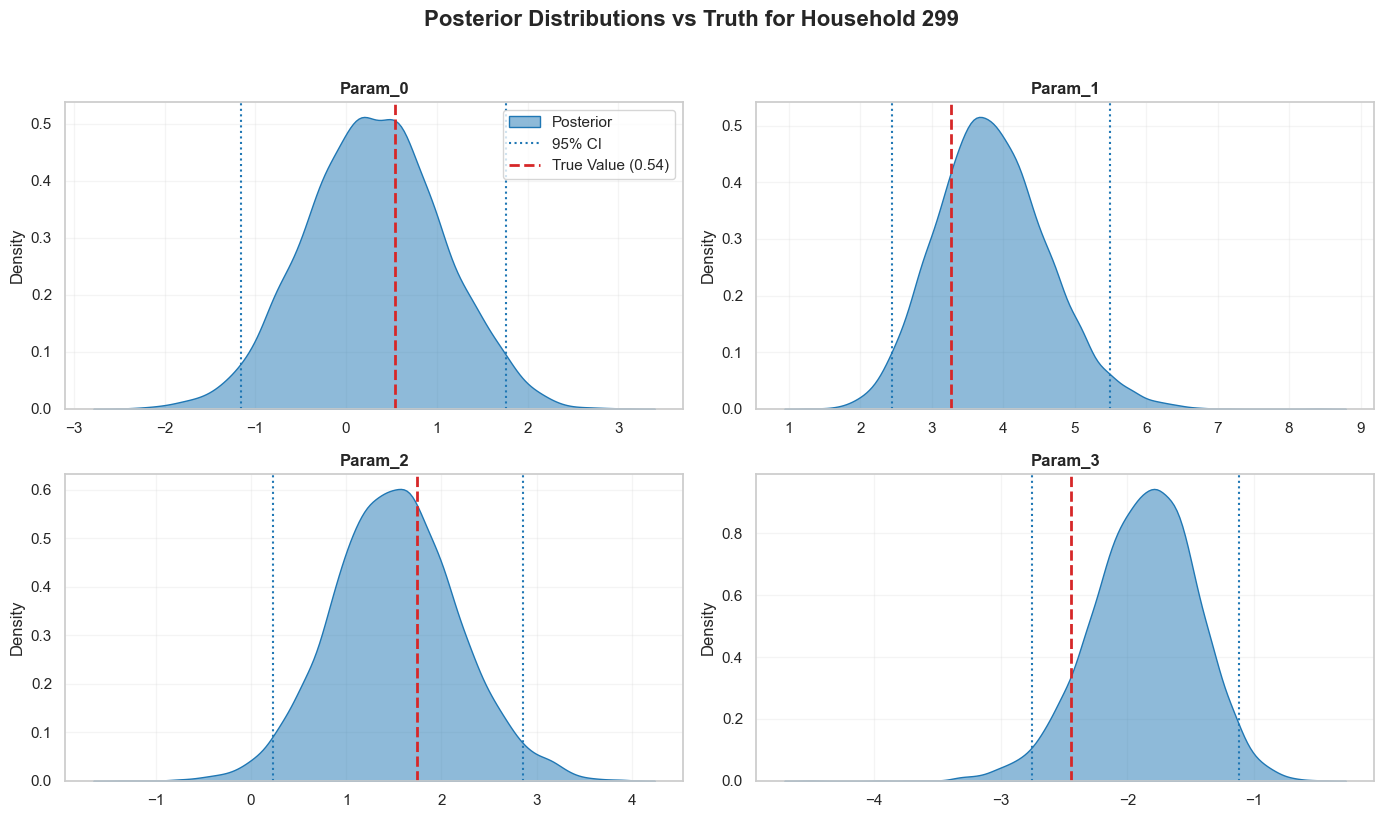

In [44]:
# ==============================================================================
# 9. HOUSEHOLD HETEROGENEITY (BETAS)
# ==============================================================================
n_chains_b, n_draws_b, n_units_b, n_params_b = posterior_samples_sorted["beta_i"].shape
liesel_beta_full = posterior_samples_sorted["beta_i"].reshape(-1, n_units_b, n_params_b)
true_betas_full  = choice_data["TRUE_BETA"]
l_beta_means     = np.mean(liesel_beta_full, axis=0)
 
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:P]
for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i],
               alpha=0.6, s=25, label=param, color=colors[i])
 
min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect Recovery')
ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Liesel Posterior Means", fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()
 
 
def plot_beta_distributions(samples, true_vals, p_names, title_prefix,
                             color_l="#1f77b4", color_t="#d62728"):
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    if len(p_names) == 1:
        axes = np.array([axes])
 
    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue
 
        l_vals = samples[:, i]
        t_val  = true_vals[i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])
 
        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5, label="Posterior")
        ax.axvline(ci_low,  color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)
        ax.axvline(t_val,   color=color_t, linestyle="--", lw=2,
                   label=f"True Value ({t_val:.2f})")
 
        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)
 
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for j2, (h, l) in enumerate(zip(handles, labels))
                      if l not in labels[:j2]]
            ax.legend(*zip(*unique), loc="upper right")
 
    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
 
 
print("\nPlotting Household-Level Distributions...")
plot_beta_distributions(
    liesel_beta_full[:, 0, :], true_betas_full[0, :], param_names,
    "Posterior Distributions vs Truth for Household 0"
)
plot_beta_distributions(
    liesel_beta_full[:, -1, :], true_betas_full[-1, :], param_names,
    f"Posterior Distributions vs Truth for Household {n_units_b - 1}"
)

In [45]:
true_betas_full

array([[-0.36071266,  2.73368634,  2.37587242,  1.36760937],
       [-0.4716326 ,  3.46993289,  3.31576126,  1.14433041],
       [ 4.36587981, -0.1925288 , -0.77709987, -0.13718362],
       ...,
       [ 2.07763582,  1.67782986, -1.26675733, -1.25161759],
       [ 3.34632645,  1.14018059, -0.21291145, -2.61750334],
       [ 0.53736793,  3.27070487,  1.7417953 , -2.44809273]],
      shape=(300, 4))

In [46]:
# ==============================================================================
# 10. LABEL-INVARIANT MIXTURE MOMENTS  (matches summary.bayesm for nmix)
# ==============================================================================
def compute_mixture_moments(pvec_samples, mu_samples, sigma_samples):
    """
    Computes label-invariant expected value and total variance of the mixture.
    Matches the output of summary(out$nmix) in bayesm.
 
    Parameters
    ----------
    pvec_samples  : (m, K)
    mu_samples    : (m, K, P)
    sigma_samples : (m, K, P, P)
 
    Returns
    -------
    mu_bar     : (m, P)    posterior draws of mixture mean
    total_var  : (m, P, P) posterior draws of mixture total variance
    """
    # Mixture mean: mu_bar = sum_k p_k * mu_k
    mu_bar = np.sum(pvec_samples[:, :, None] * mu_samples, axis=1)          # (m, P)
 
    # Within-component variance: sum_k p_k * Sigma_k
    within_var = np.sum(pvec_samples[:, :, None, None] * sigma_samples, axis=1)  # (m, P, P)
 
    # Between-component variance: sum_k p_k * (mu_k - mu_bar)(mu_k - mu_bar)'
    mu_diff  = mu_samples - mu_bar[:, None, :]                               # (m, K, P)
    between_var_components = mu_diff[:, :, :, None] @ mu_diff[:, :, None, :]  # (m, K, P, P)
    between_var = np.sum(pvec_samples[:, :, None, None] * between_var_components, axis=1)
 
    total_var = within_var + between_var
    return mu_bar, total_var
 
 
print("\nComputing Label-Invariant Mixture Moments...")
 
m_draws   = n_chains_b * n_draws_b
flat_pvec = posterior_samples_sorted["pvec"].reshape(m_draws, K)
flat_mu   = posterior_samples_sorted["mu_k"].reshape(m_draws, K, P)
flat_sigma = sigma_samples_sorted.reshape(m_draws, K, P, P)
 
post_mu_bar, post_total_var = compute_mixture_moments(flat_pvec, flat_mu, flat_sigma)
 
# True mixture moments
true_mu_bar = np.sum(choice_data["TRUE_PVEC"][:, None] * choice_data["TRUE_MU_K"], axis=0)
 
true_within_var = np.sum(
    choice_data["TRUE_PVEC"][:, None, None] * choice_data["TRUE_SIGMA_K"], axis=0
)
true_mu_diff    = choice_data["TRUE_MU_K"] - true_mu_bar
true_between_vc = true_mu_diff[:, :, None] @ true_mu_diff[:, None, :]
true_between_var = np.sum(
    choice_data["TRUE_PVEC"][:, None, None] * true_between_vc, axis=0
)
true_total_var  = true_within_var + true_between_var
 
print("\n=== Label-Invariant Expected Value (mu_bar) ===")
mu_bar_df = pd.DataFrame({
    'Parameter':      param_names,
    'True_Value':     true_mu_bar,
    'Posterior_Mean': post_mu_bar.mean(axis=0),
    'Diff_Abs':       np.abs(true_mu_bar - post_mu_bar.mean(axis=0)),
    'Posterior_Std':  post_mu_bar.std(axis=0)
}).round(4).set_index("Parameter")
display(mu_bar_df)
 
print("\n=== Label-Invariant Total Variance ===")
print("--- True Total Variance (Ground Truth) ---")
display(pd.DataFrame(true_total_var, index=param_names, columns=param_names).round(4))
 
print("\n--- Posterior Mean Total Variance ---")
mean_total_var = post_total_var.mean(axis=0)
display(pd.DataFrame(mean_total_var, index=param_names, columns=param_names).round(4))
 
print("\n--- Absolute Difference (|True - Posterior|) ---")
display(pd.DataFrame(
    np.abs(true_total_var - mean_total_var), index=param_names, columns=param_names
).round(4))



Computing Label-Invariant Mixture Moments...

=== Label-Invariant Expected Value (mu_bar) ===


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,2.0892,2.0781,0.0111,0.1186
Param_1,1.5493,1.7327,0.1833,0.1056
Param_2,-0.3199,-0.2031,0.1167,0.1255
Param_3,-1.5056,-1.4591,0.0465,0.0908



=== Label-Invariant Total Variance ===
--- True Total Variance (Ground Truth) ---


,Param_0,Param_1,Param_2,Param_3
Param_0,1.9788,-0.4852,-0.9237,-0.5448
Param_1,-0.4852,1.6489,1.0041,0.5922
Param_2,-0.9237,1.0041,2.7764,1.1275
Param_3,-0.5448,0.5922,1.1275,1.7436



--- Posterior Mean Total Variance ---


,Param_0,Param_1,Param_2,Param_3
Param_0,2.6251,-0.4758,-0.9967,-0.6917
Param_1,-0.4758,2.0254,1.1848,0.7001
Param_2,-0.9967,1.1848,2.9247,1.3697
Param_3,-0.6917,0.7001,1.3697,2.0172



--- Absolute Difference (|True - Posterior|) ---


,Param_0,Param_1,Param_2,Param_3
Param_0,0.6463,0.0093,0.0730,0.1469
Param_1,0.0093,0.3765,0.1808,0.1079
Param_2,0.0730,0.1808,0.1482,0.2422
Param_3,0.1469,0.1079,0.2422,0.2737


In [47]:
flat_pvec = posterior_samples_sorted["pvec"].reshape(-1, K)
print("Posterior mean pvec:", flat_pvec.mean(axis=0))
print("True pvec:          ", sim_data["TRUE_PVEC"])

Posterior mean pvec: [0.55203456 0.44796482]
True pvec:           [0.7 0.3]



=== pvec: Posterior Summary ===


,True_pvec,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%,True_in_CI
Component,,,,,,
0,0.7,0.552,0.0827,0.3852,0.7006,True
1,0.3,0.448,0.0827,0.2994,0.6148,True



=== pvec: Goose-Style Chain Diagnostics ===


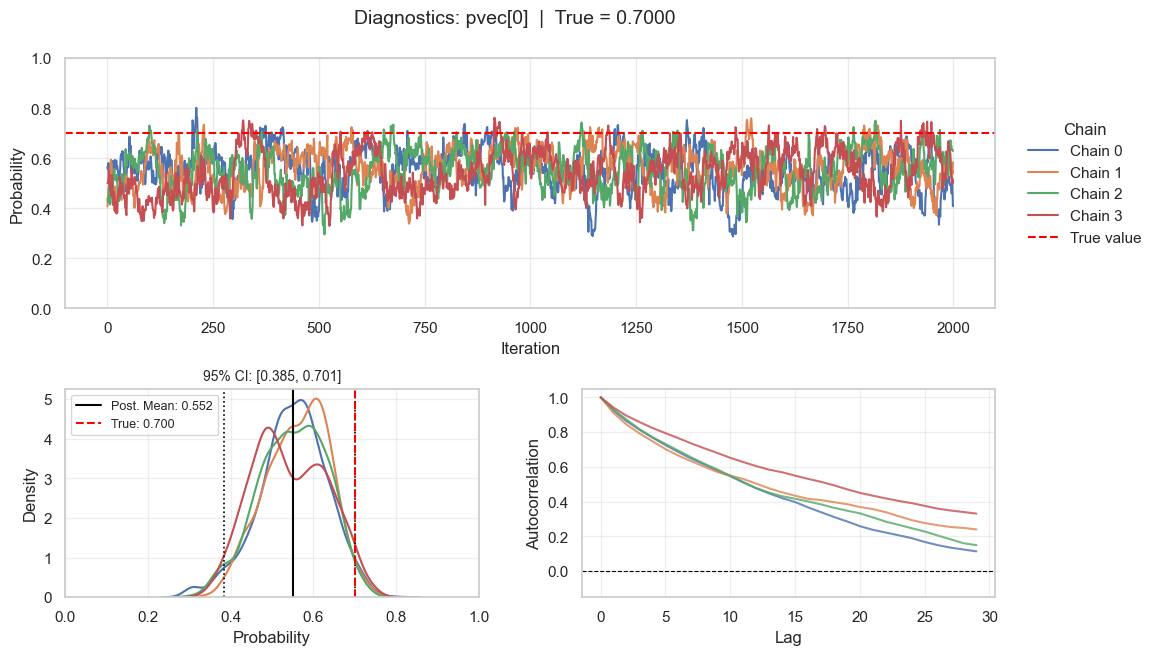

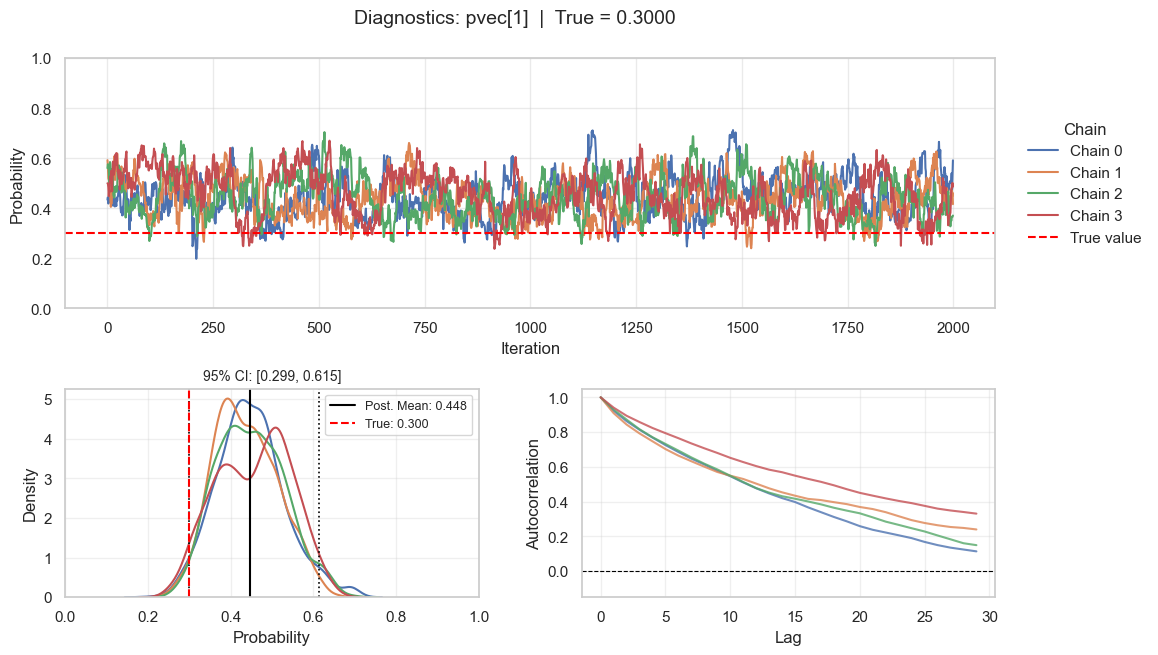

In [48]:
# ==============================================================================
# PVEC: CHAIN DIAGNOSTICS & POSTERIOR DISTRIBUTION
# ==============================================================================
def plot_pvec_diagnostics(pvec_samples_sorted, true_pvec, K, n_lags=30):
    """
    Goose-style diagnostics for each mixture probability p_k.
    
    pvec_samples_sorted : (n_chains, n_draws, K)  — already on simplex
    true_pvec           : (K,)
    """
    n_chains, n_draws, _ = pvec_samples_sorted.shape

    for k in range(K):
        fig = plt.figure(figsize=(12, 7))
        fig.suptitle(f"Diagnostics: pvec[{k}]  |  True = {true_pvec[k]:.4f}",
                     fontsize=14, y=0.95)
        gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1],
                                      hspace=0.35, wspace=0.25)

        # --- Trace ---
        ax_trace = fig.add_subplot(gs_layout[0, :])
        for chain in range(n_chains):
            ax_trace.plot(pvec_samples_sorted[chain, :, k], label=f"Chain {chain}")
        ax_trace.axhline(true_pvec[k], color="red", linestyle="--",
                         lw=1.5, label="True value")
        ax_trace.set_xlabel("Iteration")
        ax_trace.set_ylabel("Probability")
        ax_trace.set_ylim(0, 1)
        ax_trace.grid(True, alpha=0.4)
        ax_trace.legend(title="Chain", loc='center left',
                        bbox_to_anchor=(1.02, 0.5), frameon=False)

        # --- Density ---
        ax_dens = fig.add_subplot(gs_layout[1, 0])
        all_draws = pvec_samples_sorted[:, :, k].reshape(-1)
        post_mean = all_draws.mean()
        ci_low, ci_high = np.percentile(all_draws, [2.5, 97.5])

        for chain in range(n_chains):
            sns.kdeplot(pvec_samples_sorted[chain, :, k], ax=ax_dens, fill=False)
        ax_dens.axvline(post_mean,    color="black",  linestyle="-",  lw=1.5,
                        label=f"Post. Mean: {post_mean:.3f}")
        ax_dens.axvline(ci_low,       color="black",  linestyle=":",  lw=1.2)
        ax_dens.axvline(ci_high,      color="black",  linestyle=":",  lw=1.2)
        ax_dens.axvline(true_pvec[k], color="red",    linestyle="--", lw=1.5,
                        label=f"True: {true_pvec[k]:.3f}")
        ax_dens.set_xlabel("Probability")
        ax_dens.set_ylabel("Density")
        ax_dens.set_xlim(0, 1)
        ax_dens.legend(fontsize=9)
        ax_dens.grid(True, alpha=0.3)
        ax_dens.set_title(
            f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]", fontsize=10
        )

        # --- ACF ---
        ax_acf = fig.add_subplot(gs_layout[1, 1])
        for chain in range(n_chains):
            ax_acf.plot(
                compute_acf(pvec_samples_sorted[chain, :, k], nlags=n_lags),
                alpha=0.8, label=f"Chain {chain}"
            )
        ax_acf.axhline(0, color="black", lw=0.8, linestyle="--")
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylabel("Autocorrelation")
        ax_acf.set_ylim(-0.15, 1.05)
        ax_acf.grid(True, alpha=0.3)

        plt.show()


# --- Summary table ---
def pvec_summary_table(pvec_samples_sorted, true_pvec, K):
    flat = pvec_samples_sorted.reshape(-1, K)
    rows = []
    for k in range(K):
        draws = flat[:, k]
        ci_low, ci_high = np.percentile(draws, [2.5, 97.5])
        rows.append({
            "Component":     k,
            "True_pvec":     true_pvec[k],
            "Posterior_Mean": draws.mean(),
            "Posterior_Std":  draws.std(),
            "CI_2.5%":        ci_low,
            "CI_97.5%":       ci_high,
            "True_in_CI":     ci_low <= true_pvec[k] <= ci_high
        })
    return pd.DataFrame(rows).set_index("Component").round(4)


print("\n=== pvec: Posterior Summary ===")
display(pvec_summary_table(
    posterior_samples_sorted["pvec"], sim_data["TRUE_PVEC"], K
))

print("\n=== pvec: Goose-Style Chain Diagnostics ===")
plot_pvec_diagnostics(
    posterior_samples_sorted["pvec"], sim_data["TRUE_PVEC"], K
)